<a href="https://colab.research.google.com/github/Nicokac/Cartera/blob/main/Cartera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis de Portafolio — IOL + Finviz

**Módulos:**
- ⚙️ Módulo 1 — Setup e instalación
- ⚙️ Módulo 2 — Configuración: portafolio, ratios y umbrales
- 🔄 Módulo 3 — Fetch de datos (Finviz) — *ejecutar una sola vez*
- 📋 Módulo 4 — Dashboard ejecutivo (KPIs, bloques, top 5, alertas)
- 💼 Módulo 5 — Portafolio IOL detallado (MEP, valor USD, ganancias)
- 📊 Módulo 6 — Fundamentals (tabla, heatmap, P/E, Beta)
- ⭐ Módulo 7 — Ratings de analistas
- 📰 Módulo 8 — Noticias recientes
- 🕵️ Módulo 9 — Operaciones de insiders

> **Flujo recomendado:** ejecutar en orden (Run All) o por módulo.  
> El Módulo 3 hace el fetch completo (~3–4 min). Los módulos 4–9 solo visualizan los datos ya cargados.  

---

## ⚙️ Módulo 1 — Setup e instalación

In [ ]:
# Celda 1
# Dependencias base
!pip install pandas numpy --quiet

# Fuentes de datos
!pip install finvizfinance yfinance --quiet

# Visualización
!pip install matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.2 MB/s eta 0:00:00


In [ ]:
# Celda 2
import time
import warnings
from datetime import datetime, timedelta
from getpass import getpass

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from finvizfinance.quote import finvizfinance

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## ⚙️ Módulo 2 — Configuración

Editá `PORTAFOLIO`, `RATIOS` y los umbrales de alerta cuando actualices tu cartera o cuando BYMA/CNV modifique algún ratio.  
Verificar ratios en: [byma.com.ar/cedears](https://www.byma.com.ar/cedears/)

In [ ]:
# Celda 3
IOL_BASE_URL = "https://api.invertironline.com"
MARKET = "BCBA"

from datetime import datetime
from zoneinfo import ZoneInfo


def iol_login(username, password):
    resp = requests.post(
        f"{IOL_BASE_URL}/token",
        data={
            "username": username,
            "password": password,
            "grant_type": "password"
        },
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()["access_token"]


def iol_get_quote(symbol, token):
    resp = requests.get(
        f"{IOL_BASE_URL}/api/v2/{MARKET}/Titulos/{symbol}/CotizacionDetalle",
        headers={"Authorization": f"Bearer {token}"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()


use_iol_input = input("¿Querés usar una cuenta de IOL? (s/n): ").strip().lower()
USE_IOL = use_iol_input == "s"

if USE_IOL:
    from getpass import getpass

    IOL_USERNAME = getpass("Usuario IOL: ").strip()
    IOL_PASSWORD = getpass("Password IOL: ").strip()

    if not IOL_USERNAME:
        raise ValueError("IOL_USERNAME no puede estar vacío.")
    if not IOL_PASSWORD:
        raise ValueError("IOL_PASSWORD no puede estar vacío.")

    access_token = iol_login(IOL_USERNAME, IOL_PASSWORD)

    hora_argentina = datetime.now(ZoneInfo("America/Argentina/Buenos_Aires"))
    print(f"✅ Login IOL exitoso — {hora_argentina.strftime('%H:%M:%S')}")
else:
    access_token = None
    print("ℹ️ IOL no será utilizado. Continuando sin autenticación.")

¿Querés usar una cuenta de IOL? (s/n): s
Usuario IOL: ··········
Password IOL: ··········
✅ Login IOL exitoso — 19:54:55


In [ ]:
# Celda 4 final — traer portafolio real desde IOL y enriquecerlo

def iol_get_portafolio(token, pais="argentina"):
    resp = requests.get(
        f"{IOL_BASE_URL}/api/v2/portafolio/{pais}",
        headers={"Authorization": f"Bearer {token}"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()

def iol_get_estado_cuenta(token):
    resp = requests.get(
        f"{IOL_BASE_URL}/api/v2/estadocuenta",
        headers={"Authorization": f"Bearer {token}"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()

# ── Enriquecimiento local que IOL no trae como vos lo necesitás ───────────────
FINVIZ_MAP = {
    'SPY': 'SPY', 'AAPL': 'AAPL', 'T': 'T', 'MELI': 'MELI', 'IEUR': 'IEUR',
    'AMZN': 'AMZN', 'NEM': 'NEM', 'EWZ': 'EWZ', 'EEM': 'EEM', 'KO': 'KO',
    'VIST': 'VIST', 'NVDA': 'NVDA', 'V': 'V', 'BRKB': 'BRK-B', 'GOOGL': 'GOOGL',
    'MCD': 'MCD', 'XLV': 'XLV', 'MSFT': 'MSFT', 'XLU': 'XLU', 'CRM': 'CRM',
    'DIA': 'DIA', 'DISN': 'DIS', 'BABA': 'BABA', 'AMD': 'AMD',
}

BLOCK_MAP = {
    'SPY': 'Core', 'AAPL': 'Growth', 'T': 'Dividendos', 'MELI': 'Growth',
    'IEUR': 'Europa', 'AMZN': 'Growth', 'NEM': 'Commodities', 'EWZ': 'Brasil',
    'EEM': 'Emergentes', 'KO': 'Dividendos', 'VIST': 'Commodities',
    'NVDA': 'Growth', 'V': 'Growth', 'BRKB': 'Defensivo', 'GOOGL': 'Growth',
    'MCD': 'Dividendos', 'XLV': 'Defensivo', 'MSFT': 'Growth', 'XLU': 'Defensivo',
    'CRM': 'Growth', 'DIA': 'Core', 'DISN': 'Growth', 'BABA': 'Growth', 'AMD': 'Growth',
    'YPFD': 'Commodities', 'LOMA': 'Argentina', 'TECO2': 'Argentina',
    'GD30': 'Soberano AR', 'AL30': 'Soberano AR', 'BPOC7': 'Bopreal',
    'GD35': 'Soberano AR', 'TZX26': 'CER', 'TZXM6': 'CER',
    'ADBAICA': 'Liquidez', 'IOLPORA': 'Liquidez', 'PRPEDOB': 'Liquidez',
    'CAUCIÓN COLOCADORA': 'Liquidez',
}

RATIOS = {
    'SPY': 20, 'AAPL': 20, 'T': 3, 'MELI': 120,
    'IEUR': 11, 'AMZN': 144, 'NEM': 3, 'EWZ': 2,
    'EEM': 5, 'KO': 5, 'VIST': 3, 'NVDA': 24,
    'V': 18, 'BRKB': 22, 'GOOGL': 58, 'MCD': 24,
    'XLV': 29, 'MSFT': 30, 'XLU': 15, 'CRM': 18,
    'DIA': 20, 'DISN': 12, 'BABA': 9, 'AMD': 10,
}

VN_FACTOR_MAP = {
    'GD30': 100,
    'AL30': 100,
    'BPOC7': 100,
    'GD35': 100,
    'TZX26': 100,
    'TZXM6': 100,
}

ARGENTINADATOS_URL = "https://api.argentinadatos.com/v1/cotizaciones/dolares/{casa}"
MEP_CASA = "bolsa"

ALERTA_MEP_DESVIO_PCT = 5
ALERTA_PERDIDA_MINIMA = -10000

# ── 1. Traer datos reales desde IOL ───────────────────────────────────────────
portfolio_payload = iol_get_portafolio(access_token, pais="argentina")
estado_payload = iol_get_estado_cuenta(access_token)

activos = portfolio_payload.get("activos", [])
print(f"✅ Activos recibidos desde IOL: {len(activos)}")

# ── 2. Clasificar posiciones ──────────────────────────────────────────────────
PORTAFOLIO = []
ACCIONES_LOCALES = []
BONOS = []
LIQUIDEZ = []

for activo in activos:
    titulo = activo.get("titulo", {}) or {}
    simbolo = titulo.get("simbolo")
    descripcion = titulo.get("descripcion")
    tipo = str(titulo.get("tipo") or "").strip()
    tipo_norm = tipo.upper().replace(" ", "")
    moneda = str(titulo.get("moneda") or "")

    cantidad = float(activo.get("cantidad", 0) or 0)
    ppc = float(activo.get("ppc", 0) or 0)
    valorizado = float(activo.get("valorizado", 0) or 0)
    ganancia_dinero = float(activo.get("gananciaDinero", 0) or 0)

    if not simbolo:
        continue

    bloque = BLOCK_MAP.get(simbolo, "Sin clasificar")

    # CEDEARs
    if tipo_norm == "CEDEARS":
        ticker_finviz = FINVIZ_MAP.get(simbolo)
        if ticker_finviz:
            PORTAFOLIO.append((simbolo, ticker_finviz, bloque, cantidad, ppc))
        continue

    # Acciones locales
    if tipo_norm in {"ACCIONES", "ACCION"}:
        ACCIONES_LOCALES.append((simbolo, simbolo, bloque, cantidad, ppc))
        continue

    # Bonos / títulos públicos
    if tipo_norm in {"TITULOSPUBLICOS", "TITULOPUBLICO"}:
        vn_factor = VN_FACTOR_MAP.get(simbolo, 100)
        BONOS.append((simbolo, bloque, cantidad, ppc, vn_factor))
        continue

    # FCI / cash management
    if "FONDOCOMUNDEINVERSION" in tipo_norm or "FCI" in tipo_norm:
        LIQUIDEZ.append((
            simbolo,
            descripcion,
            "Liquidez",
            "USD" if "DOLAR" in descripcion.upper() or "USD" in moneda.upper() else "ARS",
            valorizado,
            ganancia_dinero
        ))
        continue

    # Caución
    if "CAUCION" in tipo_norm:
        LIQUIDEZ.append((
            "CAUCION",
            descripcion,
            "Liquidez",
            "ARS",
            valorizado,
            ganancia_dinero
        ))
        continue

# ── 3. Orden opcional para dejar salida consistente ───────────────────────────
PORTAFOLIO = sorted(PORTAFOLIO, key=lambda x: x[0])
ACCIONES_LOCALES = sorted(ACCIONES_LOCALES, key=lambda x: x[0])
BONOS = sorted(BONOS, key=lambda x: x[0])
LIQUIDEZ = sorted(LIQUIDEZ, key=lambda x: x[0])

print("✅ Configuración cargada desde IOL")
print(f"   CEDEARs:          {len(PORTAFOLIO)}")
print(f"   Acciones locales: {len(ACCIONES_LOCALES)}")
print(f"   Bonos:            {len(BONOS)}")
print(f"   Liquidez:         {len(LIQUIDEZ)}")


✅ Activos recibidos desde IOL: 35
✅ Configuración cargada desde IOL
   CEDEARs:          24
   Acciones locales: 3
   Bonos:            5
   Liquidez:         3


In [ ]:
# Celda 5
# Debug rápido de tipos reales que devuelve IOL
debug_rows = []

for activo in activos:
    titulo = activo.get("titulo", {}) or {}
    debug_rows.append({
        "simbolo": titulo.get("simbolo"),
        "descripcion": titulo.get("descripcion"),
        "tipo": titulo.get("tipo"),
        "moneda": titulo.get("moneda"),
        "cantidad": activo.get("cantidad"),
        "valorizado": activo.get("valorizado"),
    })

df_debug_iol = pd.DataFrame(debug_rows)
display(df_debug_iol.sort_values(["tipo", "simbolo"]))
print(df_debug_iol["tipo"].value_counts(dropna=False))


,simbolo,descripcion,tipo,moneda,cantidad,valorizado
19,LOMA,Loma Negra Compañia Industrial Argentina Sa,ACCIONES,peso_Argentino,35.00,113050.00
28,TECO2,Telecom Argentina,ACCIONES,peso_Argentino,21.00,71505.00
34,YPFD,Ypf,ACCIONES,peso_Argentino,6.00,405000.00
0,AAPL,Cedear Apple Inc.,CEDEARS,peso_Argentino,64.00,1198080.00
3,AMD,"Cedear Advanced Micro Devices,",CEDEARS,peso_Argentino,1.00,30000.00
4,AMZN,"Cedear Amazon.Com, Inc",CEDEARS,peso_Argentino,350.00,747950.00
5,BABA,Cedear Alibaba Group Holding L,CEDEARS,peso_Argentino,2.00,41200.00
7,BRKB,Cedear Berkshire Hathaway Inc.,CEDEARS,peso_Argentino,6.00,192600.00
8,CRM,Cedear Salesforce Inc,CEDEARS,peso_Argentino,7.00,106470.00
9,DIA,Cedear Spdr Dow Jones Industrial,CEDEARS,peso_Argentino,2.00,68040.00


tipo
CEDEARS                  24
TitulosPublicos           5
FondoComundeInversion     3
ACCIONES                  3
Name: count, dtype: int64


In [ ]:
# Celda 6 — reconstrucción de liquidez al estilo del proyecto local

import numpy as np
import pandas as pd

FCI_CASH_MANAGEMENT = {'ADBAICA', 'IOLPORA', 'PRPEDOB'}

def normalize_account_currency(moneda):
    m = str(moneda or '').strip().upper()
    if 'DOLAR' in m or 'USD' in m:
        return 'USD'
    return 'ARS'

def extract_estado_cuenta_components(estado_payload):
    cash_immediate_ars = 0.0
    cash_immediate_usd = 0.0
    cash_pending_ars = 0.0
    cash_pending_usd = 0.0
    fallback_cash_ars = 0.0
    fallback_cash_usd = 0.0
    total_broker_en_pesos = float(estado_payload.get('totalEnPesos', 0) or 0)

    for cuenta in estado_payload.get('cuentas', []):
        moneda = normalize_account_currency(cuenta.get('moneda'))
        disponible = float(cuenta.get('disponible', 0) or 0)

        if moneda == 'ARS':
            fallback_cash_ars += disponible
        else:
            fallback_cash_usd += disponible

        saldos = cuenta.get('saldos', []) or []
        if not saldos:
            continue

        immediate_found = False

        for saldo_row in saldos:
            liquidacion = str(saldo_row.get('liquidacion') or '').strip().lower()
            disponible_row = float(saldo_row.get('disponible', 0) or 0)

            if liquidacion == 'inmediato':
                immediate_found = True
                if moneda == 'ARS':
                    cash_immediate_ars += disponible_row
                else:
                    cash_immediate_usd += disponible_row
            else:
                if moneda == 'ARS':
                    cash_pending_ars += disponible_row
                else:
                    cash_pending_usd += disponible_row

        if not immediate_found:
            if moneda == 'ARS':
                cash_immediate_ars += disponible
            else:
                cash_immediate_usd += disponible

    if cash_immediate_ars == 0 and fallback_cash_ars > 0:
        cash_immediate_ars = fallback_cash_ars
    if cash_immediate_usd == 0 and fallback_cash_usd > 0:
        cash_immediate_usd = fallback_cash_usd

    return {
        'cash_immediate_ars': cash_immediate_ars,
        'cash_immediate_usd': cash_immediate_usd,
        'cash_pending_ars': cash_pending_ars,
        'cash_pending_usd': cash_pending_usd,
        'cash_disponible_ars': fallback_cash_ars,
        'cash_disponible_usd': fallback_cash_usd,
        'total_broker_en_pesos': total_broker_en_pesos,
    }

# ── 1. Reconstruir liquidez desde portafolio + estado de cuenta ──────────────
LIQUIDEZ = []

caucion_ars = 0.0
fci_cash_management_ars = 0.0

for activo in activos:
    titulo = activo.get("titulo", {}) or {}
    simbolo = str(titulo.get("simbolo") or "").strip()
    descripcion = str(titulo.get("descripcion") or "").strip()
    tipo = str(titulo.get("tipo") or "").strip()
    tipo_norm = tipo.upper().replace(" ", "")
    moneda_raw = str(titulo.get("moneda") or "")
    moneda = normalize_account_currency(moneda_raw)

    valorizado = float(activo.get("valorizado", 0) or 0)
    ganancia_dinero = float(activo.get("gananciaDinero", 0) or 0)

    # Caución detectada desde portafolio
    if "CAUCION" in tipo_norm or "CAUCION" in simbolo.upper():
        caucion_ars += valorizado
        LIQUIDEZ.append((
            "CAUCION",
            descripcion or "Caución",
            "Liquidez",
            "ARS",
            valorizado,
            ganancia_dinero
        ))
        continue

    # FCI cash management
    if simbolo.upper() in FCI_CASH_MANAGEMENT or "FONDOCOMUNDEINVERSION" in tipo_norm or "FCI" in tipo_norm:
        valorizado_ars = valorizado * mep_real if moneda == "USD" else valorizado
        ganancia_ars = ganancia_dinero * mep_real if moneda == "USD" else ganancia_dinero

        if simbolo.upper() in FCI_CASH_MANAGEMENT:
            fci_cash_management_ars += valorizado_ars

        LIQUIDEZ.append((
            simbolo,
            descripcion,
            "Liquidez",
            moneda,
            valorizado if moneda == "USD" else valorizado_ars,
            ganancia_dinero if moneda == "USD" else ganancia_ars
        ))

# ── 2. Extraer cash broker desde estadocuenta ────────────────────────────────
cash_components = extract_estado_cuenta_components(estado_payload)

cash_immediate_ars = cash_components['cash_immediate_ars']
cash_immediate_usd = cash_components['cash_immediate_usd']
cash_pending_ars = cash_components['cash_pending_ars']
cash_pending_usd = cash_components['cash_pending_usd']
total_broker_en_pesos = cash_components['total_broker_en_pesos']

# Cash disponible broker
if cash_immediate_ars > 0:
    LIQUIDEZ.append((
        'CASH_ARS',
        'Cash disponible broker ARS',
        'Liquidez',
        'ARS',
        cash_immediate_ars,
        0.0
    ))

if cash_immediate_usd > 0:
    LIQUIDEZ.append((
        'CASH_USD',
        'Cash disponible broker USD',
        'Liquidez',
        'USD',
        cash_immediate_usd,
        0.0
    ))

# Cash a liquidar, opcional como capa informativa
if cash_pending_ars > 0:
    LIQUIDEZ.append((
        'PEND_ARS',
        'Cash a liquidar ARS',
        'Liquidez',
        'ARS',
        cash_pending_ars,
        0.0
    ))

if cash_pending_usd > 0:
    LIQUIDEZ.append((
        'PEND_USD',
        'Cash a liquidar USD',
        'Liquidez',
        'USD',
        cash_pending_usd,
        0.0
    ))

# ── 3. Construir df_liquidez al estilo del proyecto local ────────────────────
registros_liquidez = []
for ticker, descripcion, bloque, moneda, valorizado_raw, ganancia_raw in LIQUIDEZ:
    if moneda == "USD":
        valorizado_ars = valorizado_raw * mep_real
        ganancia_ars = ganancia_raw * mep_real
        valor_usd = valorizado_raw
    else:
        valorizado_ars = valorizado_raw
        ganancia_ars = ganancia_raw
        valor_usd = valorizado_ars / mep_real if mep_real else np.nan

    registros_liquidez.append({
        "Ticker_IOL": ticker,
        "Descripcion": descripcion,
        "Bloque": bloque,
        "Tipo": "Liquidez",
        "Moneda": moneda,
        "Valorizado_ARS": valorizado_ars,
        "Valor_USD": value_usd if False else valor_usd,  # mantener forma explícita
        "Ganancia_ARS": ganancia_ars,
        "Cantidad": None,
        "Cantidad_Real": None,
        "PPC_ARS": None,
        "Precio_ARS": None,
    })

df_liquidez = pd.DataFrame(registros_liquidez)

if not df_liquidez.empty:
    df_liquidez = (
        df_liquidez
        .groupby(['Ticker_IOL', 'Descripcion', 'Bloque', 'Tipo', 'Moneda'], as_index=False)
        .agg({
            'Valorizado_ARS': 'sum',
            'Valor_USD': 'sum',
            'Ganancia_ARS': 'sum',
            'Cantidad': 'first',
            'Cantidad_Real': 'first',
            'PPC_ARS': 'first',
            'Precio_ARS': 'first',
        })
    )

# ── 4. Contrato de liquidez desplegable ───────────────────────────────────────
cash_disponible_broker_ars = cash_immediate_ars + cash_immediate_usd * mep_real
caucion_colocada_ars = caucion_ars
liquidez_estrategica_ars = fci_cash_management_ars
liquidez_desplegable_total_ars = (
    cash_disponible_broker_ars +
    caucion_colocada_ars +
    liquidez_estrategica_ars
)

liquidity_contract = {
    'cash_operativo_ars': round(cash_disponible_broker_ars, 2),
    'caucion_tactica_ars': round(caucion_colocada_ars, 2),
    'fci_estrategico_ars': round(liquidez_estrategica_ars, 2),
    'liquidez_desplegable_total_ars': round(liquidez_desplegable_total_ars, 2),
    'cash_operativo_usd': round(cash_disponible_broker_ars / mep_real, 2) if mep_real else np.nan,
    'caucion_tactica_usd': round(caucion_colocada_ars / mep_real, 2) if mep_real else np.nan,
    'fci_estrategico_usd': round(liquidez_estrategica_ars / mep_real, 2) if mep_real else np.nan,
    'liquidez_desplegable_total_usd': round(liquidez_desplegable_total_ars / mep_real, 2) if mep_real else np.nan,
    'total_broker_en_pesos': total_broker_en_pesos,
}

print("✅ Liquidez reconstruida con lógica del proyecto local")
print(f"Cash operativo ARS:            ${liquidity_contract['cash_operativo_ars']:,.2f}")
print(f"Caución táctica ARS:           ${liquidity_contract['caucion_tactica_ars']:,.2f}")
print(f"FCI estratégico ARS:           ${liquidity_contract['fci_estrategico_ars']:,.2f}")
print(f"Liquidez desplegable total:    ${liquidity_contract['liquidez_desplegable_total_ars']:,.2f}")
print(f"Liquidez desplegable total USD: USD {liquidity_contract['liquidez_desplegable_total_usd']:,.2f}")

display(
    df_liquidez.sort_values('Valorizado_ARS', ascending=False).style.format({
        'Valorizado_ARS': '${:,.0f}',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_ARS': '${:,.0f}',
    }, na_rep='—').set_caption('Liquidez reconstruida desde portafolio + estadocuenta')
)


NameError: name 'mep_real' is not defined

---
## 🔄 Módulo 3 — Fetch de datos (Finviz)

Consulta **en un solo loop**: precio USD, fundamentals, ratings y noticias de cada ticker.  
Tarda ~3–4 minutos. **Ejecutar una sola vez por sesión.**

In [ ]:
# Celda 7
# ── 1. MEP real desde ArgentinaDatos ─────────────────────────────────────────
mep_real = None
try:
    resp = requests.get(ARGENTINADATOS_URL.format(casa=MEP_CASA), timeout=10)
    resp.raise_for_status()
    payload = resp.json()

    if isinstance(payload, list) and payload:
        ultimo = payload[-1]
        compra = float(ultimo["compra"])
        venta = float(ultimo["venta"])
        mep_real = (compra + venta) / 2
        print(f"✅ MEP real: ${mep_real:,.2f} | Fecha: {ultimo['fecha']}")
    else:
        print("⚠️  ArgentinaDatos devolvió un payload vacío.")
except Exception as e:
    print(f"⚠️  ArgentinaDatos falló: {e} — se usará fallback al final del fetch")


# ── 2. Helpers IOL robustos ──────────────────────────────────────────────────
def iol_login(username, password):
    resp = requests.post(
        f"{IOL_BASE_URL}/token",
        data={
            "username": username,
            "password": password,
            "grant_type": "password",
        },
        timeout=30,
    )
    resp.raise_for_status()
    body = resp.json()
    return body["access_token"]


def iol_get_quote(symbol, token):
    url = f"{IOL_BASE_URL}/api/v2/{MARKET}/Titulos/{symbol}/CotizacionDetalle"
    resp = requests.get(
        url,
        headers={"Authorization": f"Bearer {token}"},
        timeout=30,
    )

    # Re-login simple si el token expiró
    if resp.status_code == 401:
        new_token = iol_login(IOL_USERNAME, IOL_PASSWORD)
        resp = requests.get(
            url,
            headers={"Authorization": f"Bearer {new_token}"},
            timeout=30,
        )
        resp.raise_for_status()
        return resp.json(), new_token

    resp.raise_for_status()
    return resp.json(), token


def parse_pct(val):
    try:
        return float(str(val).replace('%', '').replace(',', '').strip())
    except Exception:
        return None


def parse_num(val):
    try:
        return float(str(val).replace(',', '').strip())
    except Exception:
        return None


# ── 3. Precios en tiempo real desde IOL ──────────────────────────────────────
precios_iol = {}
errores_iol = []
detalles_iol = {}

todos_los_simbolos = (
    [r[0] for r in PORTAFOLIO] +
    [r[0] for r in ACCIONES_LOCALES] +
    [r[0] for r in BONOS]
)

print(f"\nObteniendo precios IOL para {len(todos_los_simbolos)} símbolos...")

for simbolo in todos_los_simbolos:
    try:
        data, access_token = iol_get_quote(simbolo, access_token)
        detalles_iol[simbolo] = data

        precio = data.get("ultimoPrecio")
        if precio is not None:
            precios_iol[simbolo] = float(precio)
            print(f"  ✅ {simbolo}: ${float(precio):,.2f}")
        else:
            errores_iol.append({"simbolo": simbolo, "motivo": "ultimoPrecio ausente"})
            print(f"  ⚠️  {simbolo}: ultimoPrecio ausente en respuesta")

    except Exception as e:
        errores_iol.append({"simbolo": simbolo, "motivo": str(e)})
        print(f"  ❌ {simbolo}: {e}")

if errores_iol:
    print("\n⚠️  Símbolos con problemas IOL:")
    for err in errores_iol:
        print(f"   - {err['simbolo']}: {err['motivo']}")


# ── 4. Construir DataFrame CEDEARs ────────────────────────────────────────────
registros_cedears = []
for ticker_iol, ticker_finviz, bloque, cantidad, ppc_ars in PORTAFOLIO:
    precio = precios_iol.get(ticker_iol)
    valorizado = cantidad * precio if precio is not None else None
    ganancia = (precio - ppc_ars) * cantidad if precio is not None else None

    registros_cedears.append({
        "Ticker_IOL": ticker_iol,
        "Ticker_Finviz": ticker_finviz,
        "Bloque": bloque,
        "Tipo": "CEDEAR",
        "Cantidad": cantidad,
        "Precio_ARS": precio,
        "PPC_ARS": ppc_ars,
        "Valorizado_ARS": valorizado,
        "Ganancia_ARS": ganancia,
    })

df = pd.DataFrame(registros_cedears)
df["Ratio"] = df["Ticker_IOL"].map(RATIOS)
df["Peso_%"] = (df["Valorizado_ARS"] / df["Valorizado_ARS"].sum() * 100).round(2)


# ── 5. Construir DataFrame acciones locales ───────────────────────────────────
registros_locales = []
for ticker_iol, ticker_api, bloque, cantidad, ppc_ars in ACCIONES_LOCALES:
    precio = precios_iol.get(ticker_iol)
    valorizado = cantidad * precio if precio is not None else None
    ganancia = (precio - ppc_ars) * cantidad if precio is not None else None

    registros_locales.append({
        "Ticker_IOL": ticker_iol,
        "Ticker_API": ticker_api,
        "Bloque": bloque,
        "Tipo": "Acción Local",
        "Cantidad": cantidad,
        "Precio_ARS": precio,
        "PPC_ARS": ppc_ars,
        "Ratio": None,
        "Ticker_Finviz": None,
        "Valorizado_ARS": valorizado,
        "Ganancia_ARS": ganancia,
    })

df_local = pd.DataFrame(registros_locales)
df_local["Peso_%"] = (df_local["Valorizado_ARS"] / df_local["Valorizado_ARS"].sum() * 100).round(2)


# ── 6. Construir DataFrame bonos ──────────────────────────────────────────────
registros_bonos = []
for ticker_iol, bloque, cantidad, ppc_ars, vn_factor in BONOS:
    precio = precios_iol.get(ticker_iol)

    cantidad_real = cantidad / vn_factor
    valorizado = cantidad_real * precio if precio is not None else None
    costo = cantidad_real * ppc_ars
    ganancia = (valorizado - costo) if valorizado is not None else None

    registros_bonos.append({
        "Ticker_IOL": ticker_iol,
        "Bloque": bloque,
        "Tipo": "Bono",
        "Cantidad": cantidad,
        "Cantidad_Real": cantidad_real,
        "VN_Factor": vn_factor,
        "Precio_ARS": precio,
        "PPC_ARS": ppc_ars,
        "Valorizado_ARS": valorizado,
        "Ganancia_ARS": ganancia,
    })

df_bonos = pd.DataFrame(registros_bonos)
df_bonos["Peso_%"] = (df_bonos["Valorizado_ARS"] / df_bonos["Valorizado_ARS"].sum() * 100).round(2)


# ── 7. Fetch Finviz — análisis fundamental ────────────────────────────────────
tickers_finviz = df["Ticker_Finviz"].dropna().unique().tolist()

CAMPOS_FUND = [
    "Company", "Sector", "Industry", "Country",
    "Market Cap", "P/E", "Fwd P/E", "EPS (ttm)",
    "Dividend", "Beta", "52W High", "52W Low",
    "Perf Week", "Perf Month", "Perf YTD",
]

precios_usd = {}
fundamentals = {}
ratings_resumen = {}
ratings_detalle = []
news_list = []
insider_list = []

total = len(tickers_finviz)
print(f"\nConsultando {total} tickers en Finviz...\n")

for i, ticker in enumerate(tickers_finviz, 1):
    try:
        stock = finvizfinance(ticker)
        data = stock.ticker_fundament()

        precio = data.get("Price")
        if precio is not None:
            precios_usd[ticker] = parse_num(precio)

        fundamentals[ticker] = {c: data.get(c) for c in CAMPOS_FUND}

        try:
            df_r = stock.ticker_outer_ratings()
            if df_r is not None and not df_r.empty:
                df_r.insert(0, "Ticker", ticker)
                ratings_detalle.append(df_r)

                action_col = next(
                    (c for c in df_r.columns if c.lower() in ["action", "rating", "status"]),
                    None,
                )
                if action_col:
                    conteo = df_r[action_col].value_counts()
                    if not conteo.empty:
                        ratings_resumen[ticker] = {
                            "total_ratings": len(df_r),
                            "consenso": conteo.index[0],
                            "consenso_n": int(conteo.iloc[0]),
                        }
        except Exception:
            pass

        try:
            df_n = stock.ticker_news()
            if df_n is not None and not df_n.empty:
                df_n.insert(0, "Ticker", ticker)
                news_list.append(df_n)
        except Exception:
            pass

        try:
            df_i = stock.ticker_inside_trader()
            if df_i is not None and not df_i.empty:
                df_i.insert(0, "Ticker", ticker)
                insider_list.append(df_i)
        except Exception:
            pass

        print(f"  [{i}/{total}] ✅ {ticker} — USD {precios_usd.get(ticker, '—')}")

    except Exception as e:
        print(f"  [{i}/{total}] ❌ {ticker} — {e}")

    time.sleep(1.2)


# ── 8. Calcular valor USD CEDEARs ─────────────────────────────────────────────
df["Precio_USD_Sub"] = df["Ticker_Finviz"].map(precios_usd)
df["Precio_USD_CEDEAR"] = df["Precio_USD_Sub"] / df["Ratio"]
df["MEP_Implicito"] = df["Precio_ARS"] / df["Precio_USD_CEDEAR"]
df["Acciones_Eq"] = df["Cantidad"] / df["Ratio"]

if mep_real is None:
    mep_real = df["MEP_Implicito"].dropna().mean()
    print(f"\n⚠️  Fallback MEP implícito promedio: ${mep_real:,.2f}")

df["Valor_USD"] = df["Valorizado_ARS"] / mep_real

for campo in CAMPOS_FUND:
    num_campos = ["P/E", "Fwd P/E", "EPS (ttm)", "Beta", "52W High", "52W Low"]
    pct_campos = ["Dividend", "Perf Week", "Perf Month", "Perf YTD"]

    if campo in num_campos:
        df[campo] = df["Ticker_Finviz"].map(lambda t, c=campo: parse_num(fundamentals.get(t, {}).get(c)))
    elif campo in pct_campos:
        df[campo] = df["Ticker_Finviz"].map(lambda t, c=campo: parse_pct(fundamentals.get(t, {}).get(c)))
    else:
        df[campo] = df["Ticker_Finviz"].map(lambda t, c=campo: fundamentals.get(t, {}).get(c))


# ── 9. Calcular valor USD acciones locales ────────────────────────────────────
df_local["MEP_Usado"] = mep_real
df_local["Acciones_Eq"] = df_local["Cantidad"]
df_local["Valor_USD"] = df_local["Valorizado_ARS"] / mep_real
df_local["Precio_USD_Sub"] = df_local["Precio_ARS"] / mep_real
df_local["Precio_USD_CEDEAR"] = df_local["Precio_USD_Sub"]
df_local["MEP_Implicito"] = None


# ── 10. Calcular valor USD bonos ──────────────────────────────────────────────
df_bonos["Valor_USD"] = df_bonos["Valorizado_ARS"] / mep_real
df_bonos["MEP_Usado"] = mep_real


# ── 11. Construir DataFrame liquidez ──────────────────────────────────────────
registros_liquidez = []
for ticker, descripcion, bloque, moneda, valorizado_ars, ganancia_ars in LIQUIDEZ:
    if moneda == "USD":
        valorizado_ars_norm = valorizado_ars * mep_real
        ganancia_ars_norm = ganancia_ars * mep_real
    else:
        valorizado_ars_norm = valorizado_ars
        ganancia_ars_norm = ganancia_ars

    registros_liquidez.append({
        "Ticker_IOL": ticker,
        "Descripcion": descripcion,
        "Bloque": bloque,
        "Tipo": "Liquidez",
        "Moneda": moneda,
        "Valorizado_ARS": valorizado_ars_norm,
        "Ganancia_ARS": ganancia_ars_norm,
        "Cantidad": None,
        "PPC_ARS": None,
        "Precio_ARS": None,
    })

df_liquidez = pd.DataFrame(registros_liquidez)
df_liquidez["Valor_USD"] = df_liquidez["Valorizado_ARS"] / mep_real
df_liquidez["Peso_%"] = (df_liquidez["Valorizado_ARS"] / df_liquidez["Valorizado_ARS"].sum() * 100).round(2)


# ── 12. DataFrames auxiliares ─────────────────────────────────────────────────
df_ratings_res = pd.DataFrame(ratings_resumen).T
df_ratings_res.index.name = "Ticker_Finviz"

df_ratings = pd.concat(ratings_detalle, ignore_index=True) if ratings_detalle else pd.DataFrame()
df_news = pd.concat(news_list, ignore_index=True) if news_list else pd.DataFrame()
df_insider = pd.concat(insider_list, ignore_index=True) if insider_list else pd.DataFrame()


# ── 13. Resumen final ─────────────────────────────────────────────────────────
usd_cedears = df["Valor_USD"].sum()
usd_locales = df_local["Valor_USD"].sum()
usd_bonos = df_bonos["Valor_USD"].sum()
usd_liquidez = df_liquidez["Valor_USD"].sum()

print(f"\n{'=' * 52}")
print(f"✅ Fetch completo — {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"   MEP real usado:   ${mep_real:,.2f} ARS/USD")
print(f"   CEDEARs:          USD {usd_cedears:>10,.2f}")
print(f"   Acciones locales: USD {usd_locales:>10,.2f}")
print(f"   Bonos:            USD {usd_bonos:>10,.2f}")
print(f"   Liquidez:         USD {usd_liquidez:>10,.2f}")
print(f"   TOTAL portafolio: USD {usd_cedears + usd_locales + usd_bonos + usd_liquidez:>10,.2f}")
print(f"   Ratings: {len(df_ratings)} | Noticias: {len(df_news)} | Insiders: {len(df_insider)}")
print(f"{'=' * 52}")


✅ MEP real: $1,434.40 | Fecha: 2026-03-30

Obteniendo precios IOL para 33 símbolos...
  ✅ AAPL: $18,270.00
  ✅ AMD: $29,060.00
  ✅ AMZN: $2,065.00
  ✅ BABA: $20,100.00
  ✅ BRKB: $32,000.00
  ✅ CRM: $15,250.00
  ✅ DIA: $33,560.00
  ✅ DISN: $11,610.00
  ✅ EEM: $16,180.00
  ✅ EWZ: $27,220.00
  ✅ GOOGL: $7,010.00
  ✅ IEUR: $9,160.00
  ✅ KO: $22,660.00
  ✅ MCD: $19,100.00
  ✅ MELI: $20,000.00
  ✅ MSFT: $17,820.00
  ✅ NEM: $50,850.00
  ✅ NVDA: $10,240.00
  ✅ SPY: $46,920.00
  ✅ T: $14,240.00
  ✅ V: $24,690.00
  ✅ VIST: $37,820.00
  ✅ XLU: $4,552.50
  ✅ XLV: $7,360.00
  ✅ LOMA: $3,090.00
  ✅ TECO2: $3,265.00
  ✅ YPFD: $68,450.00
  ✅ AL30: $86,810.00
  ✅ BPOC7: $146,730.00
  ✅ GD30: $89,200.00
  ✅ GD35: $107,650.00
  ✅ TZX26: $367.30
  ✅ TZXM6: $214.41

Consultando 24 tickers en Finviz...

  [1/24] ✅ AAPL — USD 246.63
  [2/24] ✅ AMD — USD 196.04
  [3/24] ✅ AMZN — USD 200.95
  [4/24] ✅ BABA — USD 121.98
  [5/24] ✅ BRK-B — USD 474.66
  [6/24] ✅ CRM — USD 185.03
  [7/24] ✅ DIA — USD 452.06
  [8/2

---
## 📋 Módulo 4 — Dashboard Ejecutivo

Resumen global: KPIs, distribución por bloque estratégico, top 5 ganadoras/perdedoras, consenso de analistas y alertas automáticas.

In [ ]:
# Celda 8 — resumen ejecutivo robusto

# ── 1. Normalización mínima para combinar tablas ──────────────────────────────
df = df.copy()
df_local = df_local.copy()
df_bonos = df_bonos.copy()
df_liquidez = df_liquidez.copy()

df["Cantidad_Real"] = df["Cantidad"]
df_local["Cantidad_Real"] = df_local["Cantidad"]

COLS_COMUNES = [
    "Ticker_IOL", "Bloque", "Tipo", "Cantidad", "Cantidad_Real",
    "Precio_ARS", "PPC_ARS", "Valorizado_ARS", "Ganancia_ARS", "Valor_USD"
]

for col in COLS_COMUNES:
    if col not in df.columns:
        df[col] = None
    if col not in df_local.columns:
        df_local[col] = None
    if col not in df_bonos.columns:
        df_bonos[col] = None
    if col not in df_liquidez.columns:
        df_liquidez[col] = None

df_total = pd.concat(
    [
        df[COLS_COMUNES].copy(),
        df_local[COLS_COMUNES].copy(),
        df_bonos[COLS_COMUNES].copy(),
        df_liquidez[COLS_COMUNES].copy(),
    ],
    ignore_index=True,
)

# Homogeneizar numéricos
numeric_cols = ["Cantidad", "Cantidad_Real", "Precio_ARS", "PPC_ARS", "Valorizado_ARS", "Ganancia_ARS", "Valor_USD"]
for col in numeric_cols:
    df_total[col] = pd.to_numeric(df_total[col], errors="coerce")

df_total["Es_Liquidez"] = df_total["Tipo"].eq("Liquidez")
df_total["Peso_%"] = (df_total["Valorizado_ARS"] / df_total["Valorizado_ARS"].sum() * 100).round(2)

# ── 2. KPIs globales ──────────────────────────────────────────────────────────
total_ars = df_total["Valorizado_ARS"].sum()
total_usd = df_total["Valor_USD"].sum()
ganancia_total = df_total["Ganancia_ARS"].sum()

df_invertido = df_total[~df_total["Es_Liquidez"]].copy()
df_liquidez_total = df_total[df_total["Es_Liquidez"]].copy()

invertido_ars = df_invertido["Valorizado_ARS"].sum()
invertido_usd = df_invertido["Valor_USD"].sum()

liquidez_ars = df_liquidez_total["Valorizado_ARS"].sum()
liquidez_usd = df_liquidez_total["Valor_USD"].sum()

costo_invertido = (
    df_invertido["PPC_ARS"].fillna(0) * df_invertido["Cantidad_Real"].fillna(0)
).sum()

rentabilidad_invertida = (df_invertido["Ganancia_ARS"].sum() / costo_invertido * 100) if costo_invertido > 0 else 0
rentabilidad_total = (ganancia_total / costo_invertido * 100) if costo_invertido > 0 else 0

n_ganadoras = int((df_total["Ganancia_ARS"] > 0).sum())
n_perdedoras = int((df_total["Ganancia_ARS"] < 0).sum())
n_neutras = int((df_total["Ganancia_ARS"].fillna(0) == 0).sum())

# ── 3. Breakdown por tipo ─────────────────────────────────────────────────────
resumen_tipos = (
    df_total.groupby("Tipo", dropna=False)
    .agg(
        Instrumentos=("Ticker_IOL", "count"),
        Valorizado_ARS=("Valorizado_ARS", "sum"),
        Valor_USD=("Valor_USD", "sum"),
        Ganancia_ARS=("Ganancia_ARS", "sum"),
    )
    .reset_index()
)

resumen_tipos["Peso_%"] = (
    resumen_tipos["Valorizado_ARS"] / total_ars * 100
).round(2)

resumen_tipos = resumen_tipos.sort_values("Valorizado_ARS", ascending=False).reset_index(drop=True)

# ── 4. Checks simples de integridad ───────────────────────────────────────────
faltan_precios = df_total[
    (~df_total["Es_Liquidez"]) & (df_total["Precio_ARS"].isna())
]["Ticker_IOL"].tolist()

faltan_valores_usd = df_total[df_total["Valor_USD"].isna()]["Ticker_IOL"].tolist()

peso_total = df_total["Peso_%"].sum()

# ── 5. Resumen ejecutivo ──────────────────────────────────────────────────────
print("=" * 60)
print("  RESUMEN EJECUTIVO DEL PORTAFOLIO")
print(f"  Fecha: {datetime.now().strftime('%d/%m/%Y %H:%M')}")
print("=" * 60)
print(f"  Valorizado total (ARS):        ${total_ars:>14,.2f}")
print(f"  Valor estimado total (USD):    ${total_usd:>14,.2f}")
print(f"  Ganancia total (ARS):          ${ganancia_total:>14,.2f}")
print(f"  MEP real usado:                ${mep_real:>14,.2f}")
print("-" * 60)
print(f"  Invertido (ARS):               ${invertido_ars:>14,.2f}")
print(f"  Invertido (USD):               ${invertido_usd:>14,.2f}")
print(f"  Liquidez (ARS):                ${liquidez_ars:>14,.2f}")
print(f"  Liquidez (USD):                ${liquidez_usd:>14,.2f}")
print("-" * 60)
print(f"  Costo base invertido (ARS):    ${costo_invertido:>14,.2f}")
print(f"  Rentabilidad invertida:         {rentabilidad_invertida:>13.2f}%")
print(f"  Rentabilidad total reportada:   {rentabilidad_total:>13.2f}%")
print("-" * 60)
print(f"  Posiciones ganadoras:          {n_ganadoras:>15}")
print(f"  Posiciones perdedoras:         {n_perdedoras:>15}")
print(f"  Posiciones neutras:            {n_neutras:>15}")
print(f"  Total instrumentos:            {len(df_total):>15}")
print("=" * 60)

# ── 6. Resumen por tipo ───────────────────────────────────────────────────────
print("\nResumen por tipo:")
display(resumen_tipos)

# ── 7. Top holdings y top pérdidas/ganancias ──────────────────────────────────
top_posiciones = (
    df_total.sort_values("Valorizado_ARS", ascending=False)
    [["Ticker_IOL", "Tipo", "Bloque", "Valorizado_ARS", "Valor_USD", "Peso_%"]]
    .head(10)
)

top_ganadoras = (
    df_total.sort_values("Ganancia_ARS", ascending=False)
    [["Ticker_IOL", "Tipo", "Ganancia_ARS", "Valorizado_ARS"]]
    .head(10)
)

top_perdedoras = (
    df_total.sort_values("Ganancia_ARS", ascending=True)
    [["Ticker_IOL", "Tipo", "Ganancia_ARS", "Valorizado_ARS"]]
    .head(10)
)

print("\nTop 10 posiciones por valorizado:")
display(top_posiciones)

print("\nTop 10 ganancias:")
display(top_ganadoras)

print("\nTop 10 pérdidas:")
display(top_perdedoras)

# ── 8. Alertas simples de integridad ──────────────────────────────────────────
print("\nChecks de integridad:")
print(f"  Suma de pesos: {peso_total:.2f}%")

if faltan_precios:
    print(f"  ⚠️ Sin Precio_ARS en: {faltan_precios}")
else:
    print("  ✅ Todos los instrumentos invertidos tienen Precio_ARS")

if faltan_valores_usd:
    print(f"  ⚠️ Sin Valor_USD en: {faltan_valores_usd}")
else:
    print("  ✅ Todos los instrumentos tienen Valor_USD")

if abs(peso_total - 100) > 0.2:
    print("  ⚠️ La suma de pesos se desvió materialmente de 100%")
else:
    print("  ✅ La suma de pesos es consistente")


  RESUMEN EJECUTIVO DEL PORTAFOLIO
  Fecha: 31/03/2026 04:20
  Valorizado total (ARS):        $ 26,541,068.20
  Valor estimado total (USD):    $     18,503.25
  Ganancia total (ARS):          $  3,625,388.29
  MEP real usado:                $      1,434.40
------------------------------------------------------------
  Invertido (ARS):               $ 13,897,916.18
  Invertido (USD):               $      9,689.01
  Liquidez (ARS):                $ 12,643,152.02
  Liquidez (USD):                $      8,814.24
------------------------------------------------------------
  Costo base invertido (ARS):    $ 11,366,991.28
  Rentabilidad invertida:                 22.27%
  Rentabilidad total reportada:           31.89%
------------------------------------------------------------
  Posiciones ganadoras:                       28
  Posiciones perdedoras:                       8
  Posiciones neutras:                          2
  Total instrumentos:                         38

Resumen por tipo:


,Tipo,Instrumentos,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_%
0,Liquidez,5,12643152.02,8814.24,1094463.39,47.64
1,CEDEAR,24,9970985.00,6951.33,1307222.01,37.57
2,Bono,6,3339516.18,2328.16,933517.91,12.58
3,Acción Local,3,587415.00,409.52,290184.98,2.21



Top 10 posiciones por valorizado:


,Ticker_IOL,Tipo,Bloque,Valorizado_ARS,Valor_USD,Peso_%
36,CASH_ARS,Liquidez,Liquidez,9545452.78,6654.67,35.96
33,ADBAICA,Liquidez,Liquidez,1764966.16,1230.46,6.65
19,T,CEDEAR,Dividendos,1210400.00,843.84,4.56
18,SPY,CEDEAR,Core,1173000.00,817.76,4.42
0,AAPL,CEDEAR,Growth,1169280.00,815.17,4.41
14,MELI,CEDEAR,Growth,900000.00,627.44,3.39
29,GD30,Bono,Soberano AR,896460.00,624.97,3.38
28,BPOC7,Bono,Bopreal,818753.40,570.80,3.08
34,IOLPORA,Liquidez,Liquidez,799487.70,557.37,3.01
11,IEUR,CEDEAR,Europa,787760.00,549.19,2.97



Top 10 ganancias:


,Ticker_IOL,Tipo,Ganancia_ARS,Valorizado_ARS
33,ADBAICA,Liquidez,819966.16,1764966.16
29,GD30,Bono,754035.66,896460.00
0,AAPL,CEDEAR,288908.03,1169280.00
26,YPFD,Acción Local,234165.00,410700.00
16,NEM,CEDEAR,229971.50,508500.00
19,T,CEDEAR,202974.99,1210400.00
34,IOLPORA,Liquidez,198115.43,799487.70
21,VIST,CEDEAR,183330.00,340380.00
18,SPY,CEDEAR,127196.00,1173000.00
2,AMZN,CEDEAR,121322.95,722750.00



Top 10 pérdidas:


,Ticker_IOL,Tipo,Ganancia_ARS,Valorizado_ARS
11,IEUR,CEDEAR,-52855.00,787760.00
20,V,CEDEAR,-35360.00,197520.00
5,CRM,CEDEAR,-21349.00,106750.00
8,EEM,CEDEAR,-19600.00,436860.00
4,BRKB,CEDEAR,-16840.00,192000.00
14,MELI,CEDEAR,-16007.49,900000.00
23,XLV,CEDEAR,-14040.00,132480.00
30,GD35,Bono,-13158.88,218529.50
36,CASH_ARS,Liquidez,0.00,9545452.78
37,CASH_USD,Liquidez,0.00,1749.97



Checks de integridad:
  Suma de pesos: 99.98%
  ✅ Todos los instrumentos invertidos tienen Precio_ARS
  ✅ Todos los instrumentos tienen Valor_USD
  ✅ La suma de pesos es consistente


In [ ]:
# Celda 9 — Auditoría rápida de bonos

audit_cols = [
    'Ticker_IOL', 'Cantidad', 'Cantidad_Real', 'VN_Factor',
    'Precio_ARS', 'PPC_ARS', 'Valorizado_ARS', 'Ganancia_ARS', 'Valor_USD'
]

df_bonos_audit = df_bonos[audit_cols].copy()
df_bonos_audit['Precio_x_Cantidad'] = (
    df_bonos_audit['Cantidad'] * df_bonos_audit['Precio_ARS'] / df_bonos_audit['VN_Factor']
).round(2)

df_bonos_audit['Dif_Valorizado'] = (
    df_bonos_audit['Valorizado_ARS'] - df_bonos_audit['Precio_x_Cantidad']
).round(2)

display(df_bonos_audit.sort_values('Valorizado_ARS', ascending=False))

print("Suma bonos ARS:", round(df_bonos['Valorizado_ARS'].sum(), 2))
print("Suma bonos USD:", round(df_bonos['Valor_USD'].sum(), 2))


,Ticker_IOL,Cantidad,Cantidad_Real,VN_Factor,Precio_ARS,PPC_ARS,Valorizado_ARS,Ganancia_ARS,Valor_USD,Precio_x_Cantidad,Dif_Valorizado
2,GD30,1005.00,10.05,100,89200.00,14171.58,896460.00,754035.66,624.97,896460.00,0.00
1,BPOC7,558.00,5.58,100,146730.00,143267.53,818753.40,19320.60,570.80,818753.40,0.00
4,TZX26,192703.00,1927.03,100,367.30,336.01,707798.12,60287.13,493.45,707798.12,-0.00
0,AL30,552.00,5.52,100,86810.00,69893.24,479191.20,93380.49,334.07,479191.20,-0.00
5,TZXM6,102040.00,1020.40,100,214.41,195.15,218783.96,19652.90,152.53,218783.96,0.00
3,GD35,203.00,2.03,100,107650.00,114132.21,218529.50,-13158.88,152.35,218529.50,-0.00


Suma bonos ARS: 3339516.18
Suma bonos USD: 2328.16


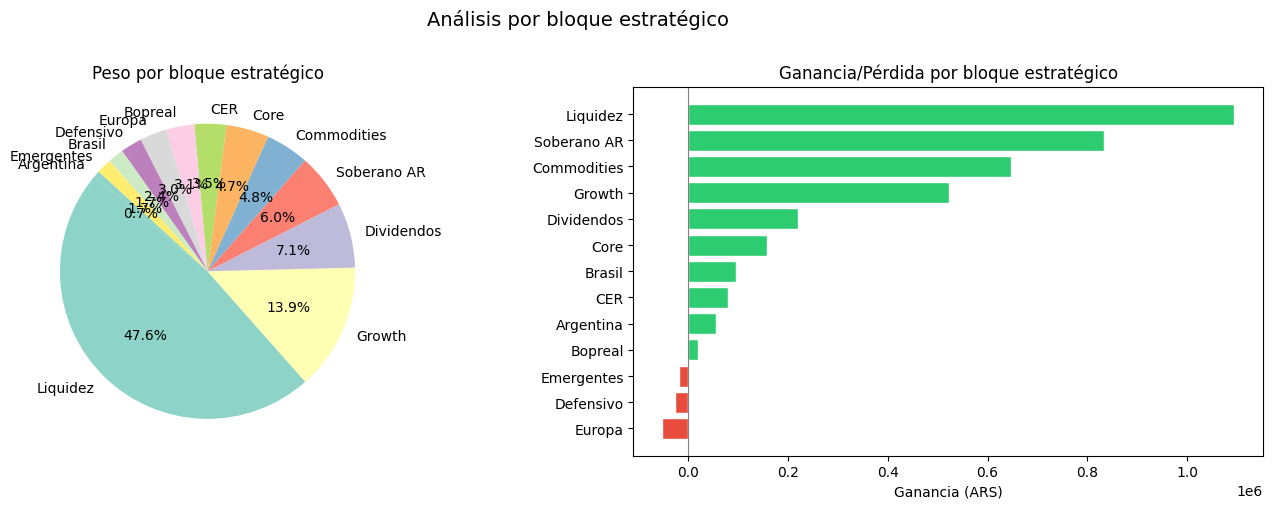

,Posiciones,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_PCT
Bloque,,,,,
Liquidez,5,"$12,643,152","USD 8,814.24","$1,094,463",47.64%
Growth,11,"$3,681,740","USD 2,566.75","$522,456",13.87%
Dividendos,3,"$1,887,940","USD 1,316.19","$219,663",7.11%
Soberano AR,3,"$1,594,181","USD 1,111.39","$834,257",6.01%
Commodities,3,"$1,259,580",USD 878.12,"$647,466",4.75%
Core,2,"$1,240,120",USD 864.56,"$156,716",4.67%
CER,2,"$926,582",USD 645.97,"$79,940",3.49%
Bopreal,1,"$818,753",USD 570.80,"$19,321",3.08%
Europa,1,"$787,760",USD 549.19,"$-52,855",2.97%


In [ ]:
# Celda 10 — Distribución por bloque estratégico

base_bloques = df_total.copy()

# Si querés excluir liquidez, descomentá esta línea:
# base_bloques = base_bloques[base_bloques['Tipo'] != 'Liquidez'].copy()

base_bloques['Bloque'] = base_bloques['Bloque'].fillna('Sin Bloque')

df_bloques = (
    base_bloques.groupby('Bloque', dropna=False)
    .agg(
        Posiciones=('Ticker_IOL', 'count'),
        Valorizado_ARS=('Valorizado_ARS', 'sum'),
        Valor_USD=('Valor_USD', 'sum'),
        Ganancia_ARS=('Ganancia_ARS', 'sum'),
    )
    .assign(Peso_PCT=lambda x: (x['Valorizado_ARS'] / x['Valorizado_ARS'].sum() * 100).round(2))
    .sort_values('Valorizado_ARS', ascending=False)
)

df_bloques_gan = df_bloques.sort_values('Ganancia_ARS', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    df_bloques['Peso_PCT'],
    labels=df_bloques.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors[:len(df_bloques)]
)
axes[0].set_title('Peso por bloque estratégico', fontsize=12)

colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_bloques_gan['Ganancia_ARS']]
axes[1].barh(df_bloques_gan.index, df_bloques_gan['Ganancia_ARS'], color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Ganancia (ARS)')
axes[1].set_title('Ganancia/Pérdida por bloque estratégico', fontsize=12)

plt.suptitle('Análisis por bloque estratégico', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

display(
    df_bloques.style
    .background_gradient(subset=['Peso_PCT'], cmap='Blues')
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .format({
        'Valorizado_ARS': '${:,.0f}',
        'Valor_USD':      'USD {:,.2f}',
        'Ganancia_ARS':   '${:,.0f}',
        'Peso_PCT':       '{:.2f}%',
    })
    .set_caption('Datos: distribución por bloque estratégico')
)


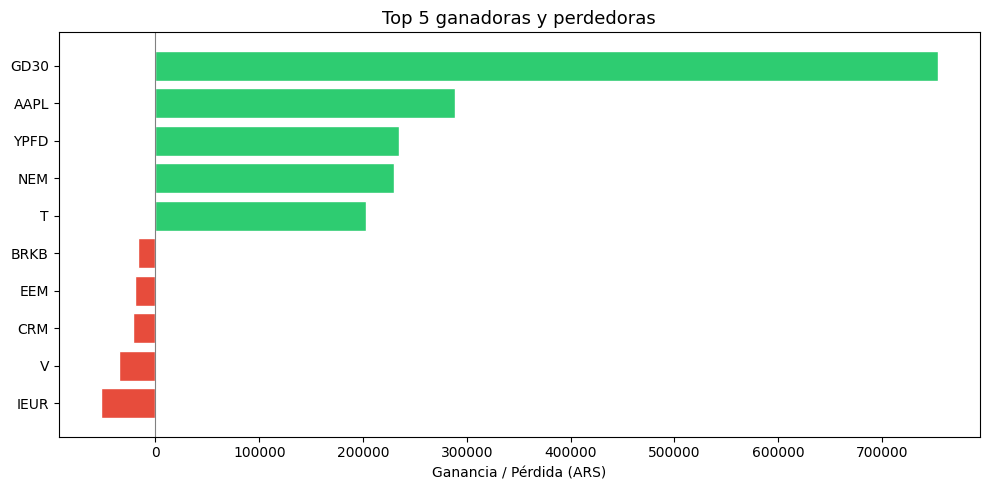


TOP 5 — Posiciones ganadoras


,Ticker_IOL,Bloque,Tipo,Ganancia_ARS,Peso_%,Valor_USD
29,GD30,Soberano AR,Bono,"$754,036",3.38%,USD 624.97
0,AAPL,Growth,CEDEAR,"$288,908",4.41%,USD 815.17
26,YPFD,Commodities,Acción Local,"$234,165",1.55%,USD 286.32
16,NEM,Commodities,CEDEAR,"$229,972",1.92%,USD 354.50
19,T,Dividendos,CEDEAR,"$202,975",4.56%,USD 843.84



TOP 5 — Posiciones perdedoras


,Ticker_IOL,Bloque,Tipo,Ganancia_ARS,Peso_%,Valor_USD
4,BRKB,Defensivo,CEDEAR,"$-16,840",0.72%,USD 133.85
8,EEM,Emergentes,CEDEAR,"$-19,600",1.65%,USD 304.56
5,CRM,Growth,CEDEAR,"$-21,349",0.40%,USD 74.42
20,V,Growth,CEDEAR,"$-35,360",0.74%,USD 137.70
11,IEUR,Europa,CEDEAR,"$-52,855",2.97%,USD 549.19


In [ ]:
# Celda 11 — Top 5 ganadoras y perdedoras

base_top = df_total.copy()

# Recomendado: excluir liquidez para no mezclar cash management con activos de riesgo
base_top = base_top[base_top['Tipo'] != 'Liquidez'].copy()

base_top = base_top[base_top['Ganancia_ARS'].notna()].copy()
base_top = base_top.sort_values('Ganancia_ARS', ascending=False)

top_gan = base_top.head(5).copy()
top_per = base_top.tail(5).copy()

combined = pd.concat([top_gan, top_per], ignore_index=True).sort_values('Ganancia_ARS')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in combined['Ganancia_ARS']]
ax.barh(combined['Ticker_IOL'], combined['Ganancia_ARS'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Ganancia / Pérdida (ARS)')
ax.set_title('Top 5 ganadoras y perdedoras', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTOP 5 — Posiciones ganadoras')
display(
    top_gan[['Ticker_IOL', 'Bloque', 'Tipo', 'Ganancia_ARS', 'Peso_%', 'Valor_USD']].style
    .background_gradient(subset=['Ganancia_ARS'], cmap='Greens')
    .format({
        'Ganancia_ARS': '${:,.0f}',
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
    })
    .set_caption('Datos: top 5 ganadoras')
)

print('\nTOP 5 — Posiciones perdedoras')
display(
    top_per[['Ticker_IOL', 'Bloque', 'Tipo', 'Ganancia_ARS', 'Peso_%', 'Valor_USD']].style
    .background_gradient(subset=['Ganancia_ARS'], cmap='Reds_r')
    .format({
        'Ganancia_ARS': '${:,.0f}',
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
    })
    .set_caption('Datos: top 5 perdedoras')
)


In [ ]:
# Celda 12 — Consenso de analistas por posición

if not df_ratings_res.empty:
    df_rat_display = df[['Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Valor_USD']].copy()
    df_rat_display = df_rat_display.merge(
        df_ratings_res.reset_index(),
        on='Ticker_Finviz',
        how='left'
    )
    df_rat_display = df_rat_display.sort_values('Valor_USD', ascending=False)

    display(
        df_rat_display[
            ['Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Valor_USD', 'total_ratings', 'consenso', 'consenso_n']
        ]
        .rename(columns={
            'Ticker_IOL': 'Ticker IOL',
            'Ticker_Finviz': 'Ticker Finviz',
            'Valor_USD': 'Valor USD',
            'total_ratings': 'Total Ratings',
            'consenso': 'Consenso',
            'consenso_n': 'Ratings del consenso',
        })
        .style
        .format({'Valor USD': 'USD {:,.2f}'}, na_rep='—')
        .set_caption('Consenso de analistas por posición')
    )
else:
    print('⚠️ No se obtuvieron ratings')


,Ticker IOL,Ticker Finviz,Bloque,Valor USD,Total Ratings,Consenso,Ratings del consenso
19,T,T,Dividendos,USD 843.84,20,Upgrade,8
18,SPY,SPY,Core,USD 817.76,—,—,—
0,AAPL,AAPL,Growth,USD 815.17,20,Reiterated,17
14,MELI,MELI,Growth,USD 627.44,20,Upgrade,7
11,IEUR,IEUR,Europa,USD 549.19,—,—,—
2,AMZN,AMZN,Growth,USD 503.87,20,Reiterated,17
12,KO,KO,Dividendos,USD 379.14,20,Reiterated,10
16,NEM,NEM,Commodities,USD 354.50,20,Upgrade,9
9,EWZ,EWZ,Brasil,USD 322.60,—,—,—
8,EEM,EEM,Emergentes,USD 304.56,—,—,—


In [ ]:
# Celda 13 — Alertas automáticas (corregida)

alertas = []

umbral_mep_alto = mep_real * (1 + ALERTA_MEP_DESVIO_PCT / 100)
umbral_mep_bajo = mep_real * (1 - ALERTA_MEP_DESVIO_PCT / 100)
UMBRAL_CONCENTRACION_PESO = 4.0

# Mapa de peso real sobre portfolio total
peso_total_map = df_total.set_index("Ticker_IOL")["Peso_%"].to_dict()

# ── CEDEARs: MEP, pérdida, beta, concentración real ──────────────────────────
for _, row in df.iterrows():
    ticker = row['Ticker_IOL']
    peso_real = peso_total_map.get(ticker)

    if pd.notna(row['Ganancia_ARS']) and row['Ganancia_ARS'] < ALERTA_PERDIDA_MINIMA:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Pérdida significativa',
            'Detalle': f"Ganancia: ${row['Ganancia_ARS']:,.0f} ARS"
        })

    if pd.notna(row['MEP_Implicito']) and row['MEP_Implicito'] > umbral_mep_alto:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'MEP implícito alto',
            'Detalle': f"MEP implícito: ${row['MEP_Implicito']:,.0f} | MEP real: ${mep_real:,.0f}"
        })

    if pd.notna(row['MEP_Implicito']) and row['MEP_Implicito'] < umbral_mep_bajo:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'MEP implícito bajo',
            'Detalle': f"MEP implícito: ${row['MEP_Implicito']:,.0f} | MEP real: ${mep_real:,.0f}"
        })

    if pd.notna(row.get('Beta')) and row['Beta'] >= 1.5 and pd.notna(peso_real) and peso_real >= 2:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Alta beta con peso relevante',
            'Detalle': f"Beta: {row['Beta']:.2f} | Peso total: {peso_real:.2f}%"
        })

    if pd.notna(peso_real) and peso_real >= UMBRAL_CONCENTRACION_PESO:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Concentración elevada',
            'Detalle': f"Peso en cartera total: {peso_real:.2f}%"
        })

# ── Acciones locales ──────────────────────────────────────────────────────────
for _, row in df_local.iterrows():
    ticker = row['Ticker_IOL']
    peso_real = peso_total_map.get(ticker)

    if pd.notna(row['Ganancia_ARS']) and row['Ganancia_ARS'] < ALERTA_PERDIDA_MINIMA:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Pérdida significativa (acción local)',
            'Detalle': f"Ganancia: ${row['Ganancia_ARS']:,.0f} ARS"
        })

    if pd.notna(peso_real) and peso_real >= UMBRAL_CONCENTRACION_PESO:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Concentración elevada (acción local)',
            'Detalle': f"Peso en cartera total: {peso_real:.2f}%"
        })

# ── Bonos ─────────────────────────────────────────────────────────────────────
for _, row in df_bonos.iterrows():
    ticker = row['Ticker_IOL']
    peso_real = peso_total_map.get(ticker)

    if pd.notna(row['Ganancia_ARS']) and row['Ganancia_ARS'] < ALERTA_PERDIDA_MINIMA:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Pérdida significativa (bono)',
            'Detalle': f"Ganancia: ${row['Ganancia_ARS']:,.0f} ARS"
        })

    if pd.notna(peso_real) and peso_real >= UMBRAL_CONCENTRACION_PESO:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Concentración elevada (bono)',
            'Detalle': f"Peso en cartera total: {peso_real:.2f}%"
        })

df_alertas = pd.DataFrame(alertas)

print(f'ALERTAS AUTOMÁTICAS ({len(alertas)} detectadas)')
print('─' * 60)

if not df_alertas.empty:
    display(
        df_alertas.style
        .hide(axis='index')
        .set_caption('Alertas del portafolio')
    )
else:
    print('✅ Sin alertas con los umbrales configurados')

print(f'\nMEP real usado:              ${mep_real:,.2f} ARS/USD')
print(f'Desvío MEP para alerta:      ±{ALERTA_MEP_DESVIO_PCT}%')
print(f'Pérdida mínima absoluta:     ${ALERTA_PERDIDA_MINIMA:,.0f} ARS')
print(f'Umbral concentración:        {UMBRAL_CONCENTRACION_PESO:.2f}%')
print('\nNota: Beta y MEP implícito aplican solo a CEDEARs con datos Finviz.')


ALERTAS AUTOMÁTICAS (12 detectadas)
────────────────────────────────────────────────────────────


Ticker,Tipo,Detalle
AAPL,Concentración elevada,Peso en cartera total: 4.41%
BRKB,Pérdida significativa,"Ganancia: $-16,840 ARS"
CRM,Pérdida significativa,"Ganancia: $-21,349 ARS"
EEM,Pérdida significativa,"Ganancia: $-19,600 ARS"
IEUR,Pérdida significativa,"Ganancia: $-52,855 ARS"
MELI,Pérdida significativa,"Ganancia: $-16,007 ARS"
MELI,Alta beta con peso relevante,Beta: 1.51 | Peso total: 3.39%
SPY,Concentración elevada,Peso en cartera total: 4.42%
T,Concentración elevada,Peso en cartera total: 4.56%
V,Pérdida significativa,"Ganancia: $-35,360 ARS"



MEP real usado:              $1,434.40 ARS/USD
Desvío MEP para alerta:      ±5%
Pérdida mínima absoluta:     $-10,000 ARS
Umbral concentración:        4.00%

Nota: Beta y MEP implícito aplican solo a CEDEARs con datos Finviz.


---
## 💼 Módulo 5 — Portafolio IOL detallado

Tabla completa con MEP implícito real, valor en USD por posición y gráficos de distribución.

In [ ]:
# Celda 14 — Tablas resumen por familia

# ── 0. Agregar peso real sobre portfolio total ────────────────────────────────
peso_total_map = df_total.set_index("Ticker_IOL")["Peso_%"].to_dict()

df = df.copy()
df_local = df_local.copy()
df_bonos = df_bonos.copy()
df_liquidez = df_liquidez.copy()

df["Peso_Portafolio_%"] = df["Ticker_IOL"].map(peso_total_map)
df_local["Peso_Portafolio_%"] = df_local["Ticker_IOL"].map(peso_total_map)
df_bonos["Peso_Portafolio_%"] = df_bonos["Ticker_IOL"].map(peso_total_map)
df_liquidez["Peso_Portafolio_%"] = df_liquidez["Ticker_IOL"].map(peso_total_map)

# ── Tabla resumen — CEDEARs ───────────────────────────────────────────────────
cols_cedears = [
    'Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Cantidad', 'Ratio', 'Acciones_Eq',
    'PPC_ARS', 'Precio_ARS', 'Precio_USD_CEDEAR', 'MEP_Implicito',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df[cols_cedears].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Acciones_Eq':         '{:.4f}',
        'PPC_ARS':             '${:,.0f}',
        'Precio_ARS':          '${:,.0f}',
        'Precio_USD_CEDEAR':   'USD {:.2f}',
        'MEP_Implicito':       '${:,.1f}',
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('CEDEARs — valor estimado en USD por posición')
)

# ── Tabla resumen — Acciones locales ─────────────────────────────────────────
cols_locales = [
    'Ticker_IOL', 'Bloque', 'Cantidad',
    'Precio_ARS', 'PPC_ARS', 'MEP_Usado',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df_local[cols_locales].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Precio_ARS':          '${:,.0f}',
        'PPC_ARS':             '${:,.0f}',
        'MEP_Usado':           '${:,.2f}',
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('Acciones locales — valor estimado en USD vía MEP real')
)

# ── Tabla resumen — Bonos ─────────────────────────────────────────────────────
cols_bonos = [
    'Ticker_IOL', 'Bloque', 'Cantidad', 'Cantidad_Real', 'VN_Factor',
    'Precio_ARS', 'PPC_ARS', 'MEP_Usado',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df_bonos[cols_bonos].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Cantidad':            '{:,.0f}',
        'Cantidad_Real':       '{:.2f}',
        'VN_Factor':           '{:,.0f}',
        'Precio_ARS':          '${:,.2f}',
        'PPC_ARS':             '${:,.2f}',
        'MEP_Usado':           '${:,.2f}',
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('Bonos — valor estimado en USD vía MEP real, normalizando por VN_Factor')
)

# ── Tabla resumen — Liquidez ──────────────────────────────────────────────────
cols_liquidez = [
    'Ticker_IOL', 'Descripcion', 'Bloque', 'Moneda',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df_liquidez[cols_liquidez].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('Liquidez — caución y FCIs')
)


,Ticker_Finviz,Bloque,Cantidad,Ratio,Acciones_Eq,PPC_ARS,Precio_ARS,Precio_USD_CEDEAR,MEP_Implicito,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_Portafolio_%
Ticker_IOL,,,,,,,,,,,,,
T,T,Dividendos,85.000000,3,28.3333,"$11,852","$14,240",USD 9.59,"$1,484.4","$1,210,400",USD 843.84,"$202,975",4.56%
SPY,SPY,Core,25.000000,20,1.2500,"$41,832","$46,920",USD 31.60,"$1,484.9","$1,173,000",USD 817.76,"$127,196",4.42%
AAPL,AAPL,Growth,64.000000,20,3.2000,"$13,756","$18,270",USD 12.33,"$1,481.6","$1,169,280",USD 815.17,"$288,908",4.41%
MELI,MELI,Growth,45.000000,120,0.3750,"$20,356","$20,000",USD 13.49,"$1,482.2","$900,000",USD 627.44,"$-16,007",3.39%
IEUR,IEUR,Europa,86.000000,11,7.8182,"$9,775","$9,160",USD 6.19,"$1,479.4","$787,760",USD 549.19,"$-52,855",2.97%
AMZN,AMZN,Growth,350.000000,144,2.4306,"$1,718","$2,065",USD 1.40,"$1,479.8","$722,750",USD 503.87,"$121,323",2.72%
KO,KO,Dividendos,24.000000,5,4.8000,"$22,438","$22,660",USD 15.25,"$1,485.5","$543,840",USD 379.14,"$5,340",2.05%
NEM,NEM,Commodities,10.000000,3,3.3333,"$27,853","$50,850",USD 34.37,"$1,479.3","$508,500",USD 354.50,"$229,972",1.92%
EWZ,EWZ,Brasil,17.000000,2,8.5000,"$21,625","$27,220",USD 18.39,"$1,480.6","$462,740",USD 322.60,"$95,110",1.74%


,Bloque,Cantidad,Precio_ARS,PPC_ARS,MEP_Usado,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_Portafolio_%
Ticker_IOL,,,,,,,,,
YPFD,Commodities,6.000000,"$68,450","$29,422","$1,434.40","$410,700",USD 286.32,"$234,165",1.55%
LOMA,Argentina,35.000000,"$3,090","$2,289","$1,434.40","$108,150",USD 75.40,"$28,027",0.41%
TECO2,Argentina,21.000000,"$3,265","$1,932","$1,434.40","$68,565",USD 47.80,"$27,993",0.26%


,Bloque,Cantidad,Cantidad_Real,VN_Factor,Precio_ARS,PPC_ARS,MEP_Usado,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_Portafolio_%
Ticker_IOL,,,,,,,,,,,
GD30,Soberano AR,"1,005",10.05,100,"$89,200.00","$14,171.58","$1,434.40","$896,460",USD 624.97,"$754,036",3.38%
BPOC7,Bopreal,558,5.58,100,"$146,730.00","$143,267.53","$1,434.40","$818,753",USD 570.80,"$19,321",3.08%
TZX26,CER,"192,703",1927.03,100,$367.30,$336.01,"$1,434.40","$707,798",USD 493.45,"$60,287",2.67%
AL30,Soberano AR,552,5.52,100,"$86,810.00","$69,893.24","$1,434.40","$479,191",USD 334.07,"$93,380",1.81%
TZXM6,CER,"102,040",1020.40,100,$214.41,$195.15,"$1,434.40","$218,784",USD 152.53,"$19,653",0.82%
GD35,Soberano AR,203,2.03,100,"$107,650.00","$114,132.21","$1,434.40","$218,529",USD 152.35,"$-13,159",0.82%


,Descripcion,Bloque,Moneda,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_Portafolio_%
Ticker_IOL,,,,,,,
CASH_ARS,Cash disponible broker ARS,Liquidez,ARS,"$9,545,453","USD 6,654.67",$0,35.96%
ADBAICA,Adcap Cobertura,Liquidez,ARS,"$1,764,966","USD 1,230.46","$819,966",6.65%
IOLPORA,IOL Portafolio Potenciado,Liquidez,ARS,"$799,488",USD 557.37,"$198,115",3.01%
PRPEDOB,Premier Performance Dolares,Liquidez,USD,"$531,495",USD 370.53,"$76,382",2.00%
CASH_USD,Cash disponible broker USD,Liquidez,USD,"$1,750",USD 1.22,$0,0.01%


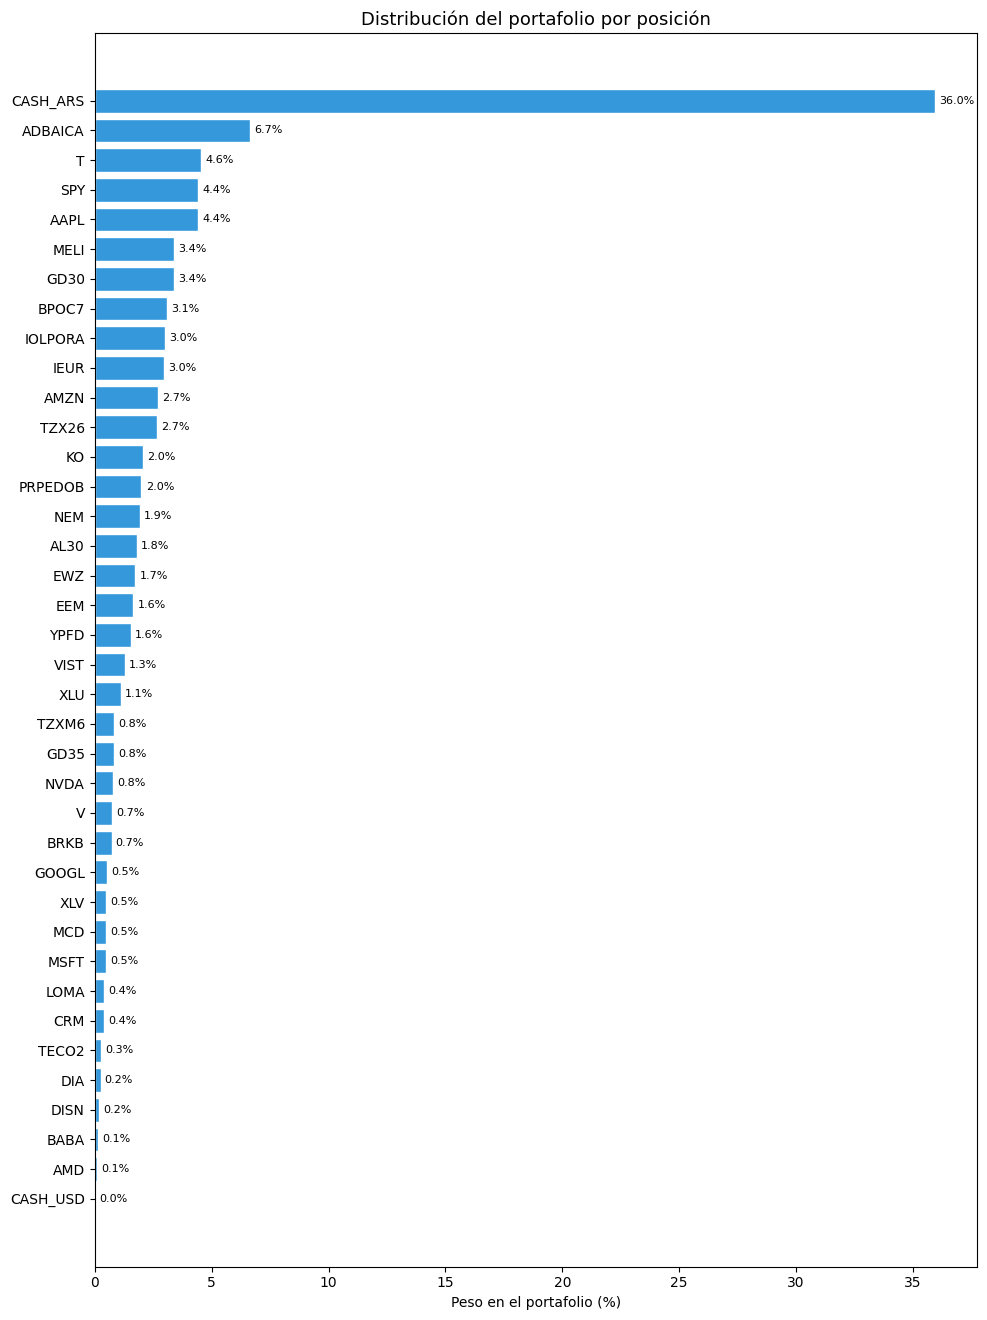

,Ticker_IOL,Peso_%,Bloque,Tipo
37,CASH_USD,0.01%,Liquidez,Liquidez
1,AMD,0.11%,Growth,CEDEAR
3,BABA,0.15%,Growth,CEDEAR
7,DISN,0.17%,Growth,CEDEAR
6,DIA,0.25%,Core,CEDEAR
25,TECO2,0.26%,Argentina,Acción Local
5,CRM,0.40%,Growth,CEDEAR
24,LOMA,0.41%,Argentina,Acción Local
15,MSFT,0.47%,Growth,CEDEAR
13,MCD,0.50%,Dividendos,CEDEAR


In [ ]:
# Celda 15 — Gráfico peso % por posición

df_peso = (
    df_total[['Ticker_IOL', 'Peso_%', 'Bloque', 'Tipo']]
    .copy()
    .sort_values('Peso_%', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_peso) * 0.35)))
bars = ax.barh(df_peso['Ticker_IOL'], df_peso['Peso_%'], color='#3498db', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xlabel('Peso en el portafolio (%)')
ax.set_title('Distribución del portafolio por posición', fontsize=13)
plt.tight_layout()
plt.show()

display(
    df_peso.style
    .background_gradient(subset=['Peso_%'], cmap='Blues')
    .format({'Peso_%': '{:.2f}%'})
    .set_caption('Datos: peso % por posición')
)


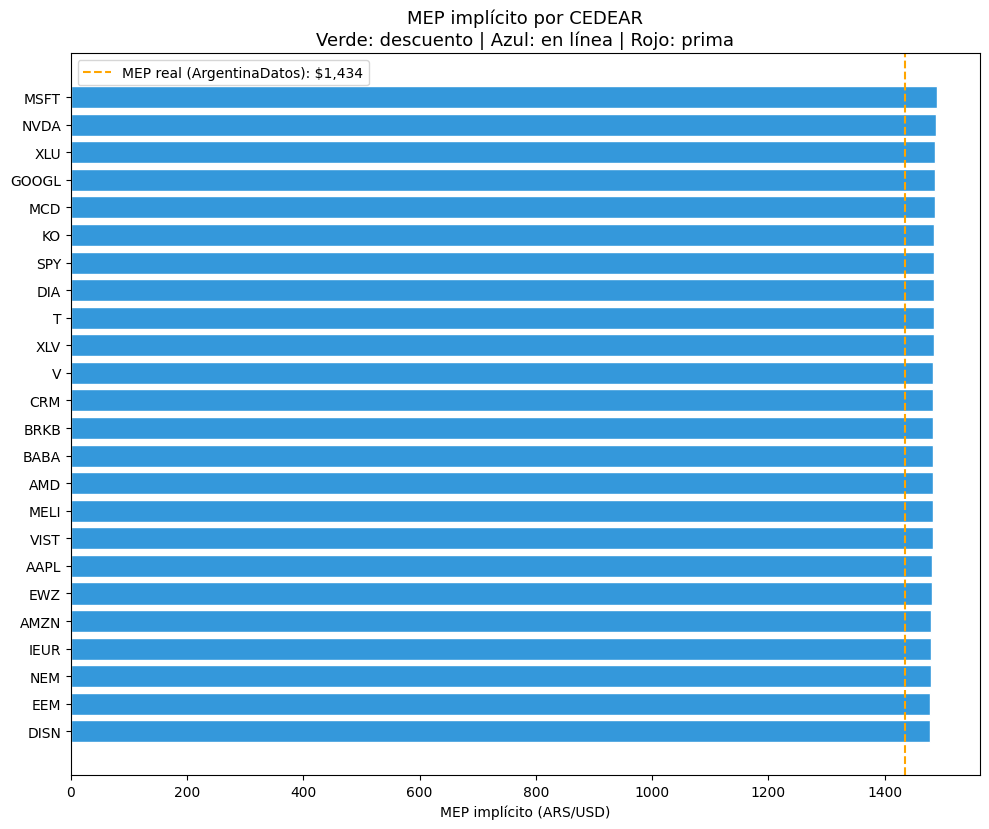

,Ticker_IOL,MEP_Implicito,vs_MEP_real,Desvio_%,Señal
7,DISN,"$1,477.1",$42.7,2.98%,En línea
8,EEM,"$1,477.6",$43.2,3.01%,En línea
16,NEM,"$1,479.3",$44.9,3.13%,En línea
11,IEUR,"$1,479.4",$45.0,3.14%,En línea
2,AMZN,"$1,479.8",$45.4,3.16%,En línea
9,EWZ,"$1,480.6",$46.2,3.22%,En línea
0,AAPL,"$1,481.6",$47.2,3.29%,En línea
21,VIST,"$1,482.2",$47.8,3.33%,En línea
14,MELI,"$1,482.2",$47.8,3.33%,En línea
1,AMD,"$1,482.4",$48.0,3.34%,En línea


In [ ]:
# Celda 16 — MEP implícito por ticker

umbral_superior = mep_real * (1 + ALERTA_MEP_DESVIO_PCT / 100)
umbral_inferior = mep_real * (1 - ALERTA_MEP_DESVIO_PCT / 100)

df_mep = (
    df[['Ticker_IOL', 'MEP_Implicito']]
    .dropna()
    .sort_values('MEP_Implicito')
    .copy()
)

colors = [
    '#e74c3c' if v > umbral_superior else
    '#2ecc71' if v < umbral_inferior else
    '#3498db'
    for v in df_mep['MEP_Implicito']
]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_mep) * 0.35)))
ax.barh(df_mep['Ticker_IOL'], df_mep['MEP_Implicito'], color=colors, edgecolor='white')
ax.axvline(
    mep_real,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'MEP real (ArgentinaDatos): ${mep_real:,.0f}'
)
ax.set_xlabel('MEP implícito (ARS/USD)')
ax.set_title('MEP implícito por CEDEAR\nVerde: descuento | Azul: en línea | Rojo: prima', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

df_mep_tabla = df_mep.copy()
df_mep_tabla['vs_MEP_real'] = df_mep_tabla['MEP_Implicito'] - mep_real
df_mep_tabla['Desvio_%'] = ((df_mep_tabla['MEP_Implicito'] - mep_real) / mep_real * 100).round(2)
df_mep_tabla['Señal'] = df_mep_tabla['Desvio_%'].apply(
    lambda x: 'Prima' if x > ALERTA_MEP_DESVIO_PCT else (
        'Descuento' if x < -ALERTA_MEP_DESVIO_PCT else 'En línea'
    )
)

display(
    df_mep_tabla.style
    .background_gradient(subset=['Desvio_%'], cmap='RdYlGn_r')
    .format({
        'MEP_Implicito': '${:,.1f}',
        'vs_MEP_real': '${:,.1f}',
        'Desvio_%': '{:.2f}%',
    })
    .set_caption(f'Datos: MEP implícito vs MEP real (${mep_real:,.0f})')
)


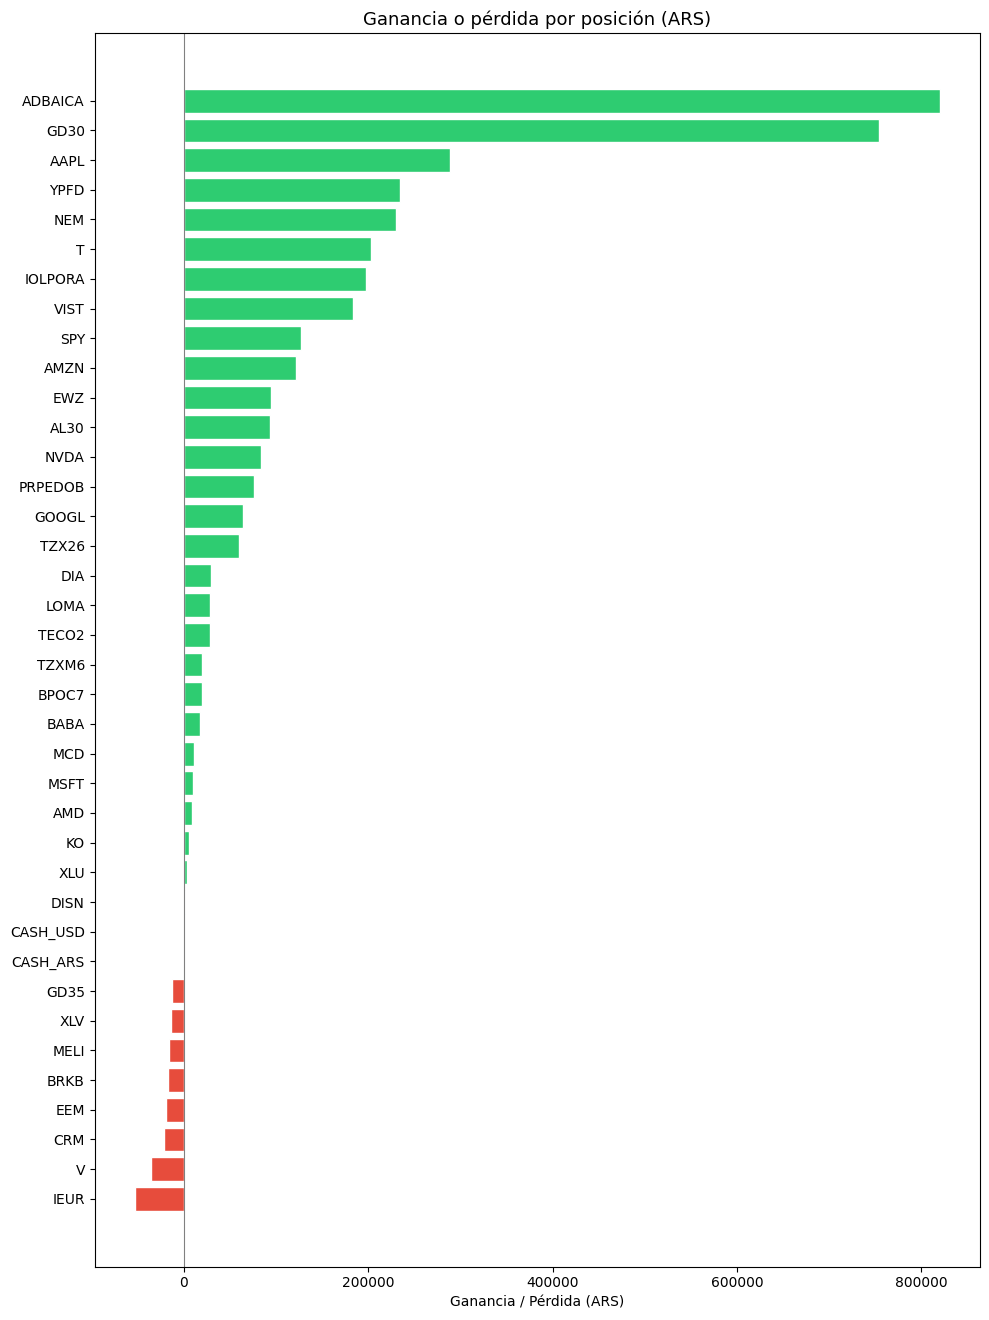

,Ticker_IOL,Ganancia_ARS,Bloque,Tipo
11,IEUR,"$-52,855",Europa,CEDEAR
20,V,"$-35,360",Growth,CEDEAR
5,CRM,"$-21,349",Growth,CEDEAR
8,EEM,"$-19,600",Emergentes,CEDEAR
4,BRKB,"$-16,840",Defensivo,CEDEAR
14,MELI,"$-16,007",Growth,CEDEAR
23,XLV,"$-14,040",Defensivo,CEDEAR
30,GD35,"$-13,159",Soberano AR,Bono
36,CASH_ARS,$0,Liquidez,Liquidez
37,CASH_USD,$0,Liquidez,Liquidez


In [ ]:
# Celda 17 — Ganancia/Pérdida en ARS por posición

base_gan = df_total.copy()

# Si querés excluir liquidez, descomentá:
# base_gan = base_gan[base_gan['Tipo'] != 'Liquidez'].copy()

df_gan = base_gan[['Ticker_IOL', 'Ganancia_ARS', 'Bloque', 'Tipo']].copy()
df_gan = df_gan[df_gan['Ganancia_ARS'].notna()].sort_values('Ganancia_ARS')

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_gan['Ganancia_ARS']]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_gan) * 0.35)))
ax.barh(df_gan['Ticker_IOL'], df_gan['Ganancia_ARS'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Ganancia / Pérdida (ARS)')
ax.set_title('Ganancia o pérdida por posición (ARS)', fontsize=13)
plt.tight_layout()
plt.show()

display(
    df_gan.style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .format({'Ganancia_ARS': '${:,.0f}'})
    .set_caption('Datos: ganancia/pérdida por posición (ARS)')
)


---
## 📋 Módulo 6 — Fundamentals

Tabla comparativa de métricas del subyacente (Finviz): P/E, EPS, Beta, performance.

In [ ]:
# Celda 18 — Tabla comparativa fundamentals Finviz

cols_fund = [
    'Company', 'Sector', 'P/E', 'Fwd P/E', 'EPS (ttm)',
    'Dividend', 'Beta', 'Perf Week', 'Perf Month', 'Perf YTD'
]
cols_fund = [c for c in cols_fund if c in df.columns]

cols_base = ['Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Valor_USD', 'Peso_%']
cols_tabla = cols_base + cols_fund

df_fund_display = df[cols_tabla].copy().sort_values('Valor_USD', ascending=False)

display(
    df_fund_display.style
    .background_gradient(subset=[c for c in ['Perf Week', 'Perf Month', 'Perf YTD'] if c in df_fund_display.columns], cmap='RdYlGn')
    .format({
        'Valor_USD': 'USD {:,.2f}',
        'Peso_%': '{:.2f}%',
        'P/E': '{:.1f}',
        'Fwd P/E': '{:.1f}',
        'EPS (ttm)': '{:.2f}',
        'Dividend': '{:.2f}%',
        'Beta': '{:.2f}',
        'Perf Week': '{:.2f}%',
        'Perf Month': '{:.2f}%',
        'Perf YTD': '{:.2f}%',
    }, na_rep='—')
    .set_caption('Fundamentals del subyacente (Finviz)')
)


,Ticker_IOL,Ticker_Finviz,Bloque,Valor_USD,Peso_%,Company,Sector,P/E,Fwd P/E,EPS (ttm),Dividend,Beta,Perf Week,Perf Month,Perf YTD
19,T,T,Dividendos,USD 843.84,12.14%,"AT&T, Inc",Communication Services,9.4,—,3.05,—,0.30,0.07%,2.75%,15.86%
18,SPY,SPY,Core,USD 817.76,11.76%,Units of undivided interest in SPDR Trust Series 1,Financial,—,—,—,—,1.01,-3.57%,-7.87%,-7.32%
0,AAPL,AAPL,Growth,USD 815.17,11.73%,Apple Inc,Technology,31.2,—,7.90,—,1.10,-1.93%,-6.64%,-9.28%
14,MELI,MELI,Growth,USD 627.44,9.03%,MercadoLibre Inc,Consumer Cyclical,41.1,—,39.39,—,1.51,-2.81%,-7.87%,-19.61%
11,IEUR,IEUR,Europa,USD 549.19,7.90%,iShares Core MSCI Europe ETF,Financial,—,—,—,—,0.88,-1.45%,-10.98%,-4.04%
2,AMZN,AMZN,Growth,USD 503.87,7.25%,Amazon.com Inc,Consumer Cyclical,28.0,—,7.17,—,1.38,-4.37%,-4.31%,-12.94%
12,KO,KO,Dividendos,USD 379.14,5.45%,Coca-Cola Co,Consumer Defensive,25.1,—,3.04,—,0.37,1.54%,-6.49%,9.10%
16,NEM,NEM,Commodities,USD 354.50,5.10%,Newmont Corp,Basic Materials,16.1,—,6.39,—,0.53,5.07%,-20.68%,3.27%
9,EWZ,EWZ,Brasil,USD 322.60,4.64%,iShares MSCI Brazil ETF,Financial,—,—,—,—,0.73,-0.22%,-5.06%,15.74%
8,EEM,EEM,Emergentes,USD 304.56,4.38%,iShares MSCI Emerging Markets ETF,Financial,—,—,—,—,0.68,-4.47%,-12.51%,0.07%


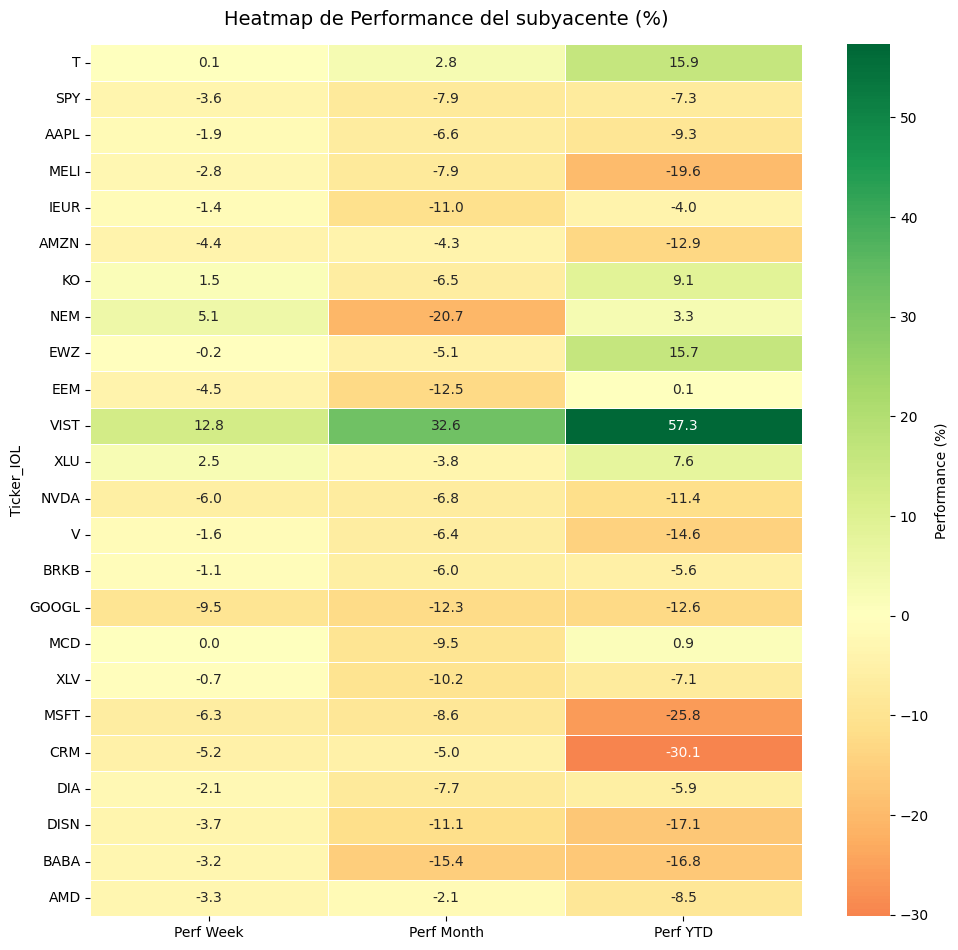

,Perf Week,Perf Month,Perf YTD
Ticker_IOL,,,
T,0.07%,2.75%,15.86%
SPY,-3.57%,-7.87%,-7.32%
AAPL,-1.93%,-6.64%,-9.28%
MELI,-2.81%,-7.87%,-19.61%
IEUR,-1.45%,-10.98%,-4.04%
AMZN,-4.37%,-4.31%,-12.94%
KO,1.54%,-6.49%,9.10%
NEM,5.07%,-20.68%,3.27%
EWZ,-0.22%,-5.06%,15.74%


In [ ]:
# Celda 19 — Heatmap performance del subyacente

perf_cols = [c for c in ['Perf Week', 'Perf Month', 'Perf YTD'] if c in df.columns]

df_perf = (
    df[['Ticker_IOL', 'Valor_USD', 'Peso_%'] + perf_cols]
    .copy()
    .sort_values('Valor_USD', ascending=False)
    .set_index('Ticker_IOL')[perf_cols]
    .dropna(how='all')
)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_perf) * 0.4)))
sns.heatmap(
    df_perf,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Performance (%)'},
    ax=ax
)
ax.set_title('Heatmap de Performance del subyacente (%)', fontsize=14, pad=14)
plt.tight_layout()
plt.show()

display(
    df_perf.style
    .background_gradient(subset=perf_cols, cmap='RdYlGn')
    .format({c: '{:.2f}%' for c in perf_cols}, na_rep='—')
    .set_caption('Datos: performance del subyacente (%)')
)


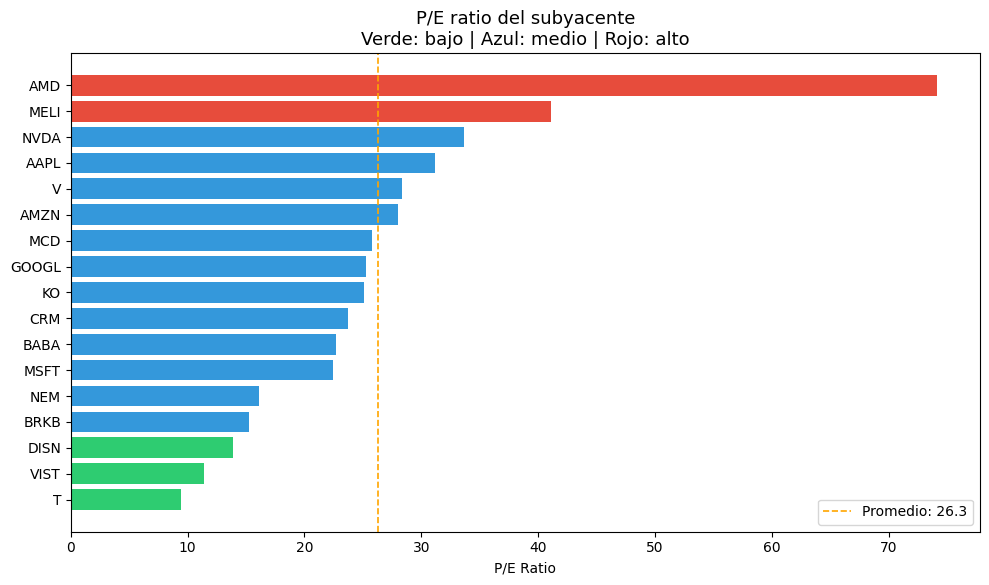

,Ticker_IOL,Bloque,Valor_USD,P/E,vs_promedio,Señal
19,T,Dividendos,USD 843.84,9.4,-16.9,P/E bajo
21,VIST,Commodities,USD 237.30,11.4,-14.9,P/E bajo
7,DISN,Growth,USD 32.38,13.9,-12.4,P/E bajo
4,BRKB,Defensivo,USD 133.85,15.3,-11.1,P/E medio
16,NEM,Commodities,USD 354.50,16.1,-10.2,P/E medio
15,MSFT,Growth,USD 86.96,22.5,-3.9,P/E medio
3,BABA,Growth,USD 28.03,22.7,-3.7,P/E medio
5,CRM,Growth,USD 74.42,23.7,-2.6,P/E medio
12,KO,Dividendos,USD 379.14,25.1,-1.2,P/E medio
10,GOOGL,Growth,USD 97.74,25.3,-1.0,P/E medio


In [ ]:
# Celda 20 — P/E ratio del subyacente

if 'P/E' in df.columns:
    base_pe = df.copy()

    # Opcional: excluir ETFs para una lectura más homogénea
    # base_pe = base_pe[base_pe['Tipo_Patrimonial'] != 'ETF'].copy() if 'Tipo_Patrimonial' in base_pe.columns else base_pe

    df_pe = (
        base_pe[['Ticker_IOL', 'P/E', 'Valor_USD', 'Bloque']]
        .dropna(subset=['P/E'])
        .sort_values('P/E')
        .copy()
    )

    promedio_pe = df_pe['P/E'].mean()

    colors = [
        '#e74c3c' if v > 40 else '#2ecc71' if v < 15 else '#3498db'
        for v in df_pe['P/E']
    ]

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_pe) * 0.35)))
    ax.barh(df_pe['Ticker_IOL'], df_pe['P/E'], color=colors)
    ax.axvline(promedio_pe, color='orange', linestyle='--', linewidth=1.2, label=f'Promedio: {promedio_pe:.1f}')
    ax.set_xlabel('P/E Ratio')
    ax.set_title('P/E ratio del subyacente\nVerde: bajo | Azul: medio | Rojo: alto', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_pe_tabla = df_pe[['Ticker_IOL', 'Bloque', 'Valor_USD', 'P/E']].copy()
    df_pe_tabla['vs_promedio'] = (df_pe_tabla['P/E'] - promedio_pe).round(2)
    df_pe_tabla['Señal'] = df_pe_tabla['P/E'].apply(
        lambda x: 'P/E alto' if x > 40 else ('P/E bajo' if x < 15 else 'P/E medio')
    )

    display(
        df_pe_tabla.style
        .background_gradient(subset=['P/E'], cmap='RdYlGn_r')
        .format({
            'Valor_USD': 'USD {:,.2f}',
            'P/E': '{:.1f}',
            'vs_promedio': '{:+.1f}',
        })
        .set_caption(f'Datos: P/E ratio (promedio simple: {promedio_pe:.1f})')
    )


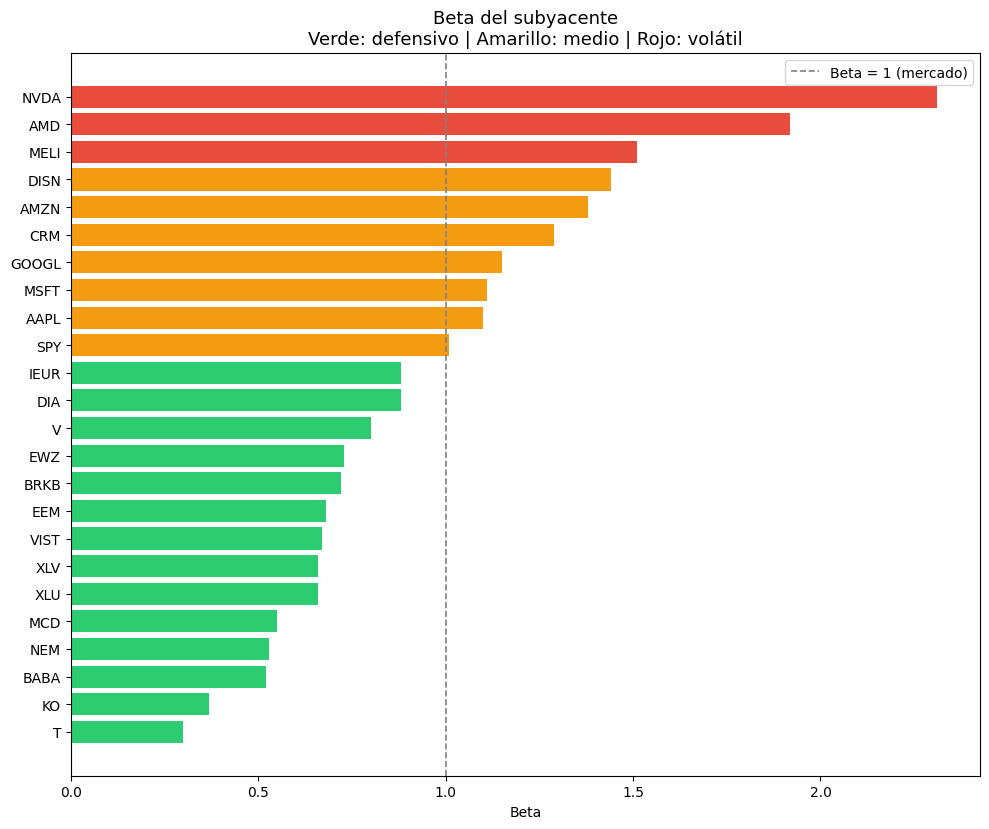

,Ticker_IOL,Beta,Valor_USD,Peso_%,Bloque,Señal
19,T,0.30,USD 843.84,12.14%,Dividendos,Defensivo
12,KO,0.37,USD 379.14,5.45%,Dividendos,Defensivo
3,BABA,0.52,USD 28.03,0.40%,Growth,Defensivo
16,NEM,0.53,USD 354.50,5.10%,Commodities,Defensivo
13,MCD,0.55,USD 93.21,1.34%,Dividendos,Defensivo
22,XLU,0.66,USD 209.47,3.01%,Defensivo,Defensivo
23,XLV,0.66,USD 92.36,1.33%,Defensivo,Defensivo
21,VIST,0.67,USD 237.30,3.41%,Commodities,Defensivo
8,EEM,0.68,USD 304.56,4.38%,Emergentes,Defensivo
4,BRKB,0.72,USD 133.85,1.93%,Defensivo,Defensivo


In [ ]:
# Celda 21 — Beta

if 'Beta' in df.columns:
    df_beta = (
        df[['Ticker_IOL', 'Beta', 'Valor_USD', 'Peso_%', 'Bloque']]
        .dropna(subset=['Beta'])
        .sort_values('Beta')
        .copy()
    )

    colors = ['#e74c3c' if v > 1.5 else '#f39c12' if v > 1 else '#2ecc71' for v in df_beta['Beta']]

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_beta) * 0.35)))
    ax.barh(df_beta['Ticker_IOL'], df_beta['Beta'], color=colors)
    ax.axvline(1, color='gray', linestyle='--', linewidth=1.2, label='Beta = 1 (mercado)')
    ax.set_xlabel('Beta')
    ax.set_title('Beta del subyacente\nVerde: defensivo | Amarillo: medio | Rojo: volátil', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_beta_tabla = df_beta.copy()
    df_beta_tabla['Señal'] = df_beta_tabla['Beta'].apply(
        lambda x: 'Alta volatilidad' if x > 1.5 else ('Moderado' if x > 1 else 'Defensivo')
    )

    display(
        df_beta_tabla.style
        .background_gradient(subset=['Beta'], cmap='RdYlGn_r')
        .format({
            'Beta': '{:.2f}',
            'Valor_USD': 'USD {:,.2f}',
            'Peso_%': '{:.2f}%',
        })
        .set_caption('Datos: Beta por ticker')
    )


---
## ⭐ Módulo 7 — Ratings de analistas

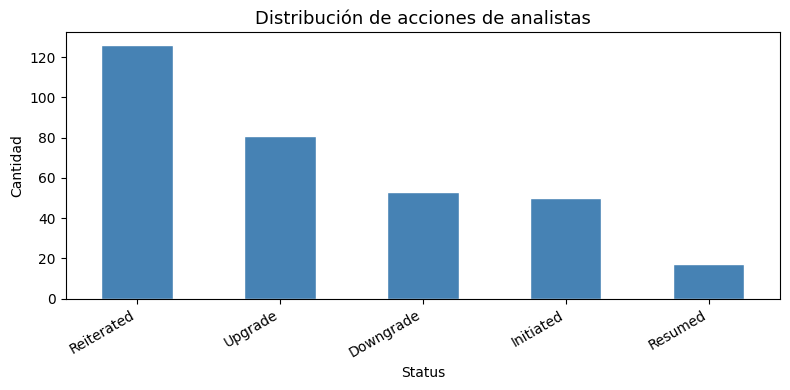

,Cantidad
Status,
Reiterated,126
Upgrade,81
Downgrade,53
Initiated,50
Resumed,17



Resumen por ticker:


,Ticker,total,consenso,consenso_n
0,AAPL,20,Reiterated,17
2,AMZN,20,Reiterated,17
13,NVDA,20,Reiterated,17
11,MSFT,20,Reiterated,16
7,GOOGL,20,Reiterated,14
1,AMD,20,Upgrade,10
8,KO,20,Reiterated,10
12,NEM,20,Upgrade,9
3,BABA,20,Upgrade,8
14,T,20,Upgrade,8



Detalle reciente de ratings:


,Ticker,Date,Status,Price
0,AAPL,2026-03-23,Reiterated,$325 → $320
1,AAPL,2026-03-05,Reiterated,$267 → $268
2,AAPL,2026-03-03,Reiterated,$239 → $248
3,AAPL,2026-02-25,Reiterated,$241 → $270
4,AAPL,2026-02-10,Reiterated,$325 → $340
5,AAPL,2026-01-30,Upgrade,$300
6,AAPL,2026-01-30,Reiterated,$250 → $267
7,AAPL,2026-01-30,Reiterated,$300 → $315
8,AAPL,2026-01-30,Reiterated,$315 → $325
9,AAPL,2026-01-30,Reiterated,$230 → $239


In [ ]:
# Celda 22 — Ratings de analistas

if not df_ratings.empty:
    action_col = next((c for c in df_ratings.columns if c.lower() in ['action', 'rating', 'status']), None)

    if action_col:
        base_ratings = df_ratings.copy()
        base_ratings = base_ratings[base_ratings[action_col].notna()].copy()

        conteo = base_ratings[action_col].value_counts()

        fig, ax = plt.subplots(figsize=(8, 4))
        conteo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title('Distribución de acciones de analistas', fontsize=13)
        ax.set_ylabel('Cantidad')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

        display(
            conteo.to_frame(name='Cantidad').style
            .background_gradient(cmap='Blues')
            .set_caption('Datos: distribución de acciones de analistas')
        )

        resumen_por_ticker = (
            base_ratings.groupby('Ticker')[action_col]
            .agg(
                total='count',
                consenso=lambda s: s.value_counts().index[0] if not s.value_counts().empty else None,
                consenso_n=lambda s: int(s.value_counts().iloc[0]) if not s.value_counts().empty else None,
            )
            .reset_index()
            .sort_values(['total', 'consenso_n'], ascending=False)
        )

        print("\nResumen por ticker:")
        display(
            resumen_por_ticker.style
            .format({'total': '{:,.0f}', 'consenso_n': '{:,.0f}'}, na_rep='—')
            .set_caption('Resumen de ratings por ticker')
        )

        detalle_cols = [c for c in ['Ticker', 'Date', 'Publisher', action_col, 'Price Target', 'Price', 'Analyst'] if c in base_ratings.columns]

        print("\nDetalle reciente de ratings:")
        display(base_ratings[detalle_cols].head(40))
    else:
        print('⚠️ No se encontró una columna de acción/rating/status en df_ratings')
else:
    print('⚠️ Sin datos de ratings')


---
## 📰 Módulo 8 — Noticias recientes por ticker

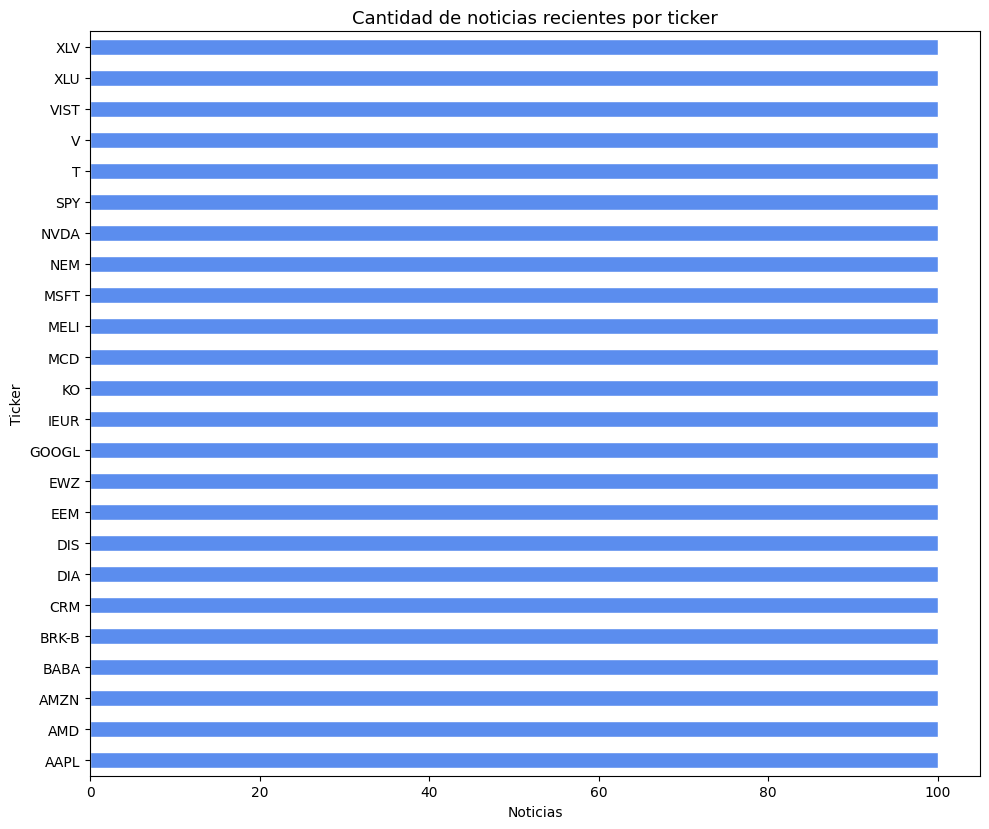

,Noticias
Ticker,
AAPL,100
AMD,100
AMZN,100
BABA,100
BRK-B,100
CRM,100
DIA,100
DIS,100
EEM,100


,Ticker,Date,Title,Link
0,AAPL,2026-03-30 20:58:00,Apple's removal of vibe coding apps sparks debate over security and competition,Ver
1,AAPL,2026-03-30 14:36:00,Apple Stock at a Crossroads: How Are Options Traders Reacting?,Ver
2,AAPL,2026-03-30 13:18:00,This Qualcomm Call Feels Like A Warning,Ver
3,AAPL,2026-03-30 12:05:00,iPhone Demand Holds Strong in China Despite Market Slump,Ver
4,AAPL,2026-03-30 09:59:00,Big Tech Stocks Rout Is Flashing Signals of a Turnaround,Ver
5,AMD,2026-03-30 19:33:00,Zalando s Supervisory Board Nominates AI Pioneer Peter Sarlin to Strengthen AI Leadership and Drive Innovation,Ver
6,AMD,2026-03-30 17:36:00,This Stock Popped 15% in Its Trading Debut. Meet Quantum's New Kid on the Block.,Ver
7,AMD,2026-03-30 16:09:00,This Stock Looks Like a Solid AI Bet-and Wall Street Hasn't Noticed Yet,Ver
8,AMD,2026-03-30 14:41:00,"Chip Stocks Falls as Sector Selloff Deepens, Optical Names Lead Losses",Ver
9,AMD,2026-03-30 14:36:00,Intel Faces Pressure as Core CPU Business Weakens,Ver


In [ ]:
# Celda 23 — Noticias recientes

if not df_news.empty:
    base_news = df_news.copy()

    conteo_news = base_news.groupby('Ticker').size().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(5, len(conteo_news) * 0.35)))
    conteo_news.plot(kind='barh', ax=ax, color='#5b8dee', edgecolor='white')
    ax.set_title('Cantidad de noticias recientes por ticker', fontsize=13)
    ax.set_xlabel('Noticias')
    plt.tight_layout()
    plt.show()

    display(
        conteo_news.to_frame(name='Noticias').style
        .background_gradient(cmap='Blues')
        .format({'Noticias': '{:.0f}'})
        .set_caption('Datos: cobertura de noticias por ticker')
    )

    date_col = next((c for c in base_news.columns if 'date' in c.lower() or 'time' in c.lower()), None)
    title_col = next((c for c in base_news.columns if 'title' in c.lower() or 'headline' in c.lower() or 'news' == c.lower()), None)
    link_col = next((c for c in base_news.columns if 'link' in c.lower() or 'url' in c.lower()), None)

    if date_col:
        try:
            base_news = base_news.sort_values(['Ticker', date_col], ascending=[True, False])
        except Exception:
            pass

    df_news_top = base_news.groupby('Ticker').head(5).reset_index(drop=True)

    cols_show = [c for c in ['Ticker', date_col, title_col, link_col] if c]
    if not cols_show:
        cols_show = df_news_top.columns.tolist()[:5]

    if link_col and link_col in cols_show:
        display(
            df_news_top[cols_show].style.format(
                {link_col: lambda url: f'<a href="{url}" target="_blank">Ver</a>' if pd.notna(url) else '—'}
            ).set_caption('Últimas 5 noticias por ticker')
        )
    else:
        display(
            df_news_top[cols_show].style.set_caption('Últimas 5 noticias por ticker')
        )
else:
    print('⚠️ Sin noticias')


---
## 🕵️ Módulo 9 — Operaciones de insiders

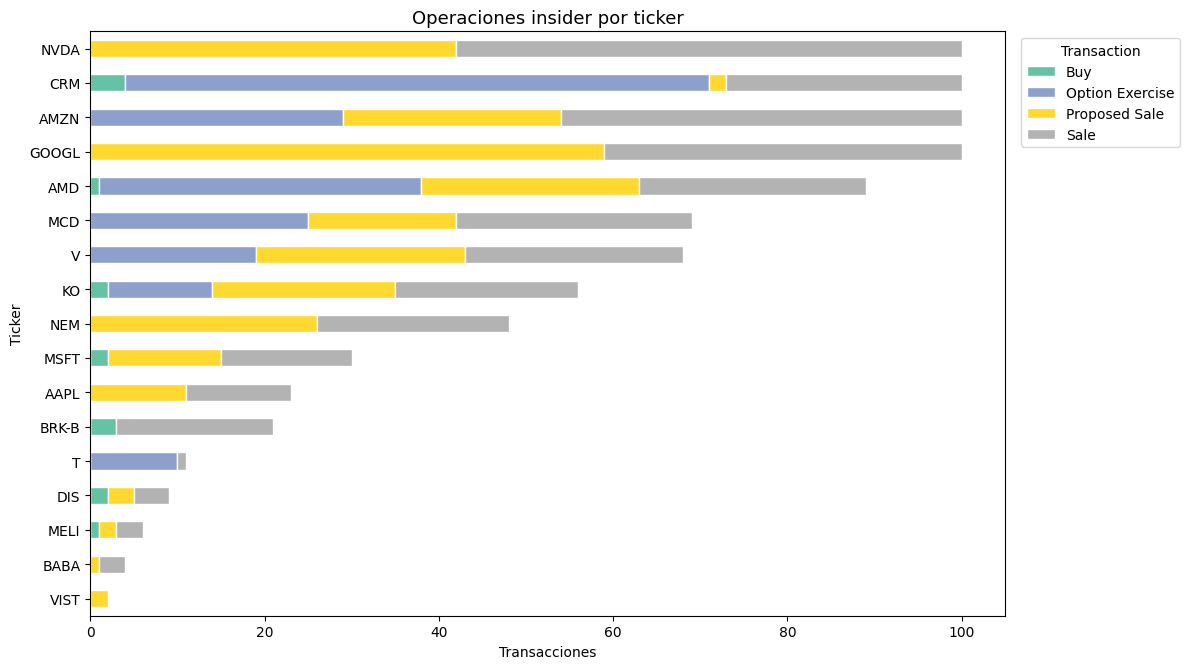

Transaction,Buy,Option Exercise,Proposed Sale,Sale,Total
Ticker,,,,,
VIST,0,0,2,0,2
BABA,0,0,1,3,4
MELI,1,0,2,3,6
DIS,2,0,3,4,9
T,0,10,0,1,11
BRK-B,3,0,0,18,21
AAPL,0,0,11,12,23
MSFT,2,0,13,15,30
NEM,0,0,26,22,48



Detalle reciente de insiders:


,Ticker,Date,Transaction,Relationship
335,CRM,Sep 30 '25,Option Exercise,Chair and CEO
336,CRM,Sep 30 '25,Sale,Chair and CEO
432,GOOGL,Sep 30 '25,Sale,Director
433,GOOGL,Sep 30 '25,Proposed Sale,Director
743,NVDA,Sep 30 '25,Sale,President and CEO
746,NVDA,Sep 30 '25,Proposed Sale,Officer
429,GOOGL,Sep 29 '25,Sale,"President, Global Affairs, CLO"
434,GOOGL,Sep 29 '25,Proposed Sale,Officer
747,NVDA,Sep 29 '25,Sale,President and CEO
750,NVDA,Sep 29 '25,Proposed Sale,Officer


In [ ]:
# Celda 24 — Insiders

if not df_insider.empty:
    base_insider = df_insider.copy()

    trans_col = next(
        (c for c in base_insider.columns if c.lower() in ['transaction', 'type', 'option type', 'action']),
        None
    )

    if trans_col:
        base_insider = base_insider[base_insider[trans_col].notna()].copy()

        pivot = base_insider.groupby(['Ticker', trans_col]).size().unstack(fill_value=0)
        pivot['Total'] = pivot.sum(axis=1)
        pivot = pivot.sort_values('Total', ascending=True)
        pivot_plot = pivot.drop(columns=['Total'])

        fig, ax = plt.subplots(figsize=(12, max(5, len(pivot_plot) * 0.4)))
        pivot_plot.plot(kind='barh', ax=ax, stacked=True, colormap='Set2', edgecolor='white')
        ax.set_title('Operaciones insider por ticker', fontsize=13)
        ax.set_xlabel('Transacciones')
        ax.legend(title=trans_col, bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        display(
            pivot.style
            .background_gradient(cmap='Blues')
            .set_caption('Datos: operaciones insider por ticker y tipo')
        )

        date_col = next((c for c in base_insider.columns if 'date' in c.lower() or 'time' in c.lower()), None)
        cols_show = [c for c in ['Ticker', date_col, trans_col, 'Shares', 'Value', 'Owner', 'Relationship'] if c in base_insider.columns]

        detalle = base_insider.copy()
        if date_col:
            try:
                detalle = detalle.sort_values(date_col, ascending=False)
            except Exception:
                pass

        print("\nDetalle reciente de insiders:")
        if cols_show:
            display(detalle[cols_show].head(40))
        else:
            display(detalle.head(40))
    else:
        print('⚠️ No se encontró una columna de tipo de transacción insider')
else:
    print('⚠️ Sin datos insider')


In [ ]:
# Celda 25 — checks de integridad

checks = []

checks.append({
    "check": "MEP real disponible",
    "status": "OK" if pd.notna(mep_real) and mep_real > 0 else "ERROR",
    "detalle": f"mep_real={mep_real}"
})

checks.append({
    "check": "df_total no vacío",
    "status": "OK" if not df_total.empty else "ERROR",
    "detalle": f"filas={len(df_total)}"
})

checks.append({
    "check": "Pesos suman ~100%",
    "status": "OK" if abs(df_total["Peso_%"].sum() - 100) <= 0.2 else "WARN",
    "detalle": f"suma={df_total['Peso_%'].sum():.2f}%"
})

checks.append({
    "check": "Bonos valorizados",
    "status": "OK" if df_bonos["Valorizado_ARS"].notna().all() else "WARN",
    "detalle": f"faltantes={df_bonos['Valorizado_ARS'].isna().sum()}"
})

checks.append({
    "check": "CEDEARs con MEP implícito",
    "status": "OK" if df["MEP_Implicito"].notna().all() else "WARN",
    "detalle": f"faltantes={df['MEP_Implicito'].isna().sum()}"
})

checks.append({
    "check": "Finviz con precio USD",
    "status": "OK" if df["Precio_USD_Sub"].notna().all() else "WARN",
    "detalle": f"faltantes={df['Precio_USD_Sub'].isna().sum()}"
})

df_checks = pd.DataFrame(checks)
display(df_checks.style.hide(axis="index").set_caption("Checks de integridad"))


check,status,detalle
MEP real disponible,OK,mep_real=1434.4
df_total no vacío,OK,filas=38
Pesos suman ~100%,OK,suma=99.98%
Bonos valorizados,OK,faltantes=0
CEDEARs con MEP implícito,OK,faltantes=0
Finviz con precio USD,OK,faltantes=0


In [ ]:
# Celda 26 — exposición cruzada por tipo y bloque

df_mix = (
    df_total.groupby(["Tipo", "Bloque"], dropna=False)
    .agg(
        posiciones=("Ticker_IOL", "count"),
        valorizado_ars=("Valorizado_ARS", "sum"),
        valor_usd=("Valor_USD", "sum"),
        ganancia_ars=("Ganancia_ARS", "sum"),
    )
    .reset_index()
)

df_mix["peso_%"] = (df_mix["valorizado_ars"] / df_mix["valorizado_ars"].sum() * 100).round(2)
df_mix = df_mix.sort_values(["Tipo", "valorizado_ars"], ascending=[True, False])

display(
    df_mix.style
    .format({
        "valorizado_ars": "${:,.0f}",
        "valor_usd": "USD {:,.2f}",
        "ganancia_ars": "${:,.0f}",
        "peso_%": "{:.2f}%"
    }, na_rep="—")
    .set_caption("Exposición por tipo y bloque")
)


,Tipo,Bloque,posiciones,valorizado_ars,valor_usd,ganancia_ars,peso_%
1,Acción Local,Commodities,1,"$410,700",USD 286.32,"$234,165",1.55%
0,Acción Local,Argentina,2,"$176,715",USD 123.20,"$56,020",0.67%
4,Bono,Soberano AR,3,"$1,594,181","USD 1,111.39","$834,257",6.01%
3,Bono,CER,2,"$926,582",USD 645.97,"$79,940",3.49%
2,Bono,Bopreal,1,"$818,753",USD 570.80,"$19,321",3.08%
12,CEDEAR,Growth,11,"$3,681,740","USD 2,566.75","$522,456",13.87%
9,CEDEAR,Dividendos,3,"$1,887,940","USD 1,316.19","$219,663",7.11%
7,CEDEAR,Core,2,"$1,240,120",USD 864.56,"$156,716",4.67%
6,CEDEAR,Commodities,2,"$848,880",USD 591.80,"$413,302",3.20%
11,CEDEAR,Europa,1,"$787,760",USD 549.19,"$-52,855",2.97%


In [ ]:
# Celda 27 — dashboard final condensado

top_peso = df_total.sort_values("Peso_%", ascending=False)[["Ticker_IOL", "Tipo", "Bloque", "Peso_%"]].head(10)
top_gan = df_total.sort_values("Ganancia_ARS", ascending=False)[["Ticker_IOL", "Tipo", "Ganancia_ARS"]].head(5)
top_per = df_total.sort_values("Ganancia_ARS", ascending=True)[["Ticker_IOL", "Tipo", "Ganancia_ARS"]].head(5)

print("=" * 60)
print("DASHBOARD FINAL")
print("=" * 60)
print(f"Total ARS:   ${df_total['Valorizado_ARS'].sum():,.0f}")
print(f"Total USD:   USD {df_total['Valor_USD'].sum():,.2f}")
print(f"Ganancia:    ${df_total['Ganancia_ARS'].sum():,.0f}")
print(f"MEP real:    ${mep_real:,.2f}")
print("=" * 60)

print("\nTop 10 por peso")
display(top_peso.style.format({"Peso_%": "{:.2f}%"}))

print("\nTop 5 ganadoras")
display(top_gan.style.format({"Ganancia_ARS": "${:,.0f}"}))

print("\nTop 5 perdedoras")
display(top_per.style.format({"Ganancia_ARS": "${:,.0f}"}))


DASHBOARD FINAL
Total ARS:   $26,541,068
Total USD:   USD 18,503.25
Ganancia:    $3,625,388
MEP real:    $1,434.40

Top 10 por peso


,Ticker_IOL,Tipo,Bloque,Peso_%
36,CASH_ARS,Liquidez,Liquidez,35.96%
33,ADBAICA,Liquidez,Liquidez,6.65%
19,T,CEDEAR,Dividendos,4.56%
18,SPY,CEDEAR,Core,4.42%
0,AAPL,CEDEAR,Growth,4.41%
14,MELI,CEDEAR,Growth,3.39%
29,GD30,Bono,Soberano AR,3.38%
28,BPOC7,Bono,Bopreal,3.08%
34,IOLPORA,Liquidez,Liquidez,3.01%
11,IEUR,CEDEAR,Europa,2.97%



Top 5 ganadoras


,Ticker_IOL,Tipo,Ganancia_ARS
33,ADBAICA,Liquidez,"$819,966"
29,GD30,Bono,"$754,036"
0,AAPL,CEDEAR,"$288,908"
26,YPFD,Acción Local,"$234,165"
16,NEM,CEDEAR,"$229,972"



Top 5 perdedoras


,Ticker_IOL,Tipo,Ganancia_ARS
11,IEUR,CEDEAR,"$-52,855"
20,V,CEDEAR,"$-35,360"
5,CRM,CEDEAR,"$-21,349"
8,EEM,CEDEAR,"$-19,600"
4,BRKB,CEDEAR,"$-16,840"


In [ ]:
# Celda 28 — score_refuerzo y score_reduccion (corregida)

import numpy as np
import pandas as pd

def rank_score(series, higher_is_better=True, neutral=0.5):
    s = pd.to_numeric(series, errors='coerce')
    out = pd.Series(neutral, index=s.index, dtype=float)
    valid = s.notna()
    if valid.any():
        ranks = s[valid].rank(pct=True, method='average')
        out.loc[valid] = ranks if higher_is_better else (1 - ranks)
    return out

def consensus_to_score(text):
    if pd.isna(text):
        return 0.5
    t = str(text).strip().lower()

    positivos = ['buy', 'outperform', 'overweight', 'upgrade', 'positive', 'strong buy', 'initiated']
    negativos = ['sell', 'underperform', 'underweight', 'downgrade', 'negative', 'reduce']
    neutros = ['hold', 'neutral', 'equal-weight', 'equal weight', 'market perform', 'sector perform', 'reiterated']

    if any(x in t for x in positivos):
        return 1.0
    if any(x in t for x in negativos):
        return 0.0
    if any(x in t for x in neutros):
        return 0.5
    return 0.5

# ── 1. Base unificada ─────────────────────────────────────────────────────────
decision_cols = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valorizado_ARS',
    'Valor_USD', 'Ganancia_ARS', 'Cantidad_Real', 'PPC_ARS'
]
base = df_total[decision_cols].copy()

base['Costo_ARS'] = base['Cantidad_Real'].fillna(0) * base['PPC_ARS'].fillna(0)
base['Ganancia_%'] = np.where(
    base['Costo_ARS'] > 0,
    base['Ganancia_ARS'] / base['Costo_ARS'] * 100,
    np.nan
)

ced_cols = [
    'Ticker_IOL', 'Ticker_Finviz', 'Perf Week', 'Perf Month', 'Perf YTD',
    'Beta', 'P/E', 'MEP_Implicito'
]
ced_data = df[ced_cols].copy()

if not df_ratings_res.empty:
    ratings_map = df_ratings_res.reset_index()[['Ticker_Finviz', 'consenso', 'consenso_n', 'total_ratings']].copy()
    ced_data = ced_data.merge(ratings_map, on='Ticker_Finviz', how='left')
else:
    ced_data['consenso'] = None
    ced_data['consenso_n'] = np.nan
    ced_data['total_ratings'] = np.nan

decision = base.merge(ced_data, on='Ticker_IOL', how='left')

decision['Cobertura_Modelo'] = np.where(decision['Ticker_Finviz'].notna(), 'Completa', 'Parcial')
decision['Es_Liquidez'] = decision['Tipo'].eq('Liquidez')
decision['Es_Cedear'] = decision['Tipo'].eq('CEDEAR')
decision['Es_Bono'] = decision['Tipo'].eq('Bono')
decision['Es_Accion_Local'] = decision['Tipo'].eq('Acción Local')
decision['Es_Core'] = decision['Bloque'].eq('Core')

decision['MEP_Premium_%'] = np.where(
    decision['MEP_Implicito'].notna(),
    (decision['MEP_Implicito'] / mep_real - 1) * 100,
    np.nan
)

decision['Consensus_Score'] = decision['consenso'].apply(consensus_to_score)
decision['Consensus_Strength'] = np.where(
    decision['total_ratings'].fillna(0) > 0,
    decision['consenso_n'].fillna(0) / decision['total_ratings'].fillna(1),
    np.nan
)
decision['Consensus_Final'] = (
    0.7 * decision['Consensus_Score'].fillna(0.5) +
    0.3 * decision['Consensus_Strength'].fillna(0.5)
)

# Ganancia normalizada para evitar outliers absurdos en bonos
decision['Ganancia_%_Cap'] = decision['Ganancia_%'].clip(lower=-100, upper=150)

# ── 2. Scores parciales ───────────────────────────────────────────────────────
decision['s_low_weight'] = rank_score(decision['Peso_%'], higher_is_better=False)
decision['s_high_weight'] = rank_score(decision['Peso_%'], higher_is_better=True)

decision['s_mom_week'] = rank_score(decision['Perf Week'], higher_is_better=True)
decision['s_mom_month'] = rank_score(decision['Perf Month'], higher_is_better=True)
decision['s_mom_ytd'] = rank_score(decision['Perf YTD'], higher_is_better=True)

decision['s_weak_mom_week'] = rank_score(decision['Perf Week'], higher_is_better=False)
decision['s_weak_mom_month'] = rank_score(decision['Perf Month'], higher_is_better=False)
decision['s_weak_mom_ytd'] = rank_score(decision['Perf YTD'], higher_is_better=False)

decision['s_beta_ok'] = rank_score(decision['Beta'], higher_is_better=False)
decision['s_beta_risk'] = rank_score(decision['Beta'], higher_is_better=True)

decision['s_pe_ok'] = rank_score(decision['P/E'], higher_is_better=False)
decision['s_pe_expensive'] = rank_score(decision['P/E'], higher_is_better=True)

decision['s_mep_ok'] = rank_score(decision['MEP_Premium_%'], higher_is_better=False)
decision['s_mep_premium'] = rank_score(decision['MEP_Premium_%'], higher_is_better=True)

decision['s_consensus_good'] = decision['Consensus_Final'].fillna(0.5)
decision['s_consensus_bad'] = 1 - decision['s_consensus_good']

decision['s_big_gain'] = rank_score(decision['Ganancia_%_Cap'], higher_is_better=True)
decision['s_big_loss'] = rank_score(decision['Ganancia_%_Cap'], higher_is_better=False)

decision['Momentum_Refuerzo'] = (
    0.2 * decision['s_mom_week'] +
    0.4 * decision['s_mom_month'] +
    0.4 * decision['s_mom_ytd']
)

decision['Momentum_Reduccion'] = (
    0.2 * decision['s_weak_mom_week'] +
    0.4 * decision['s_weak_mom_month'] +
    0.4 * decision['s_weak_mom_ytd']
)

# ── 3. Score refuerzo ─────────────────────────────────────────────────────────
decision['score_refuerzo'] = (
    0.20 * decision['s_low_weight'] +
    0.25 * decision['Momentum_Refuerzo'] +
    0.15 * decision['s_consensus_good'] +
    0.10 * decision['s_beta_ok'] +
    0.10 * decision['s_mep_ok'] +
    0.10 * decision['s_pe_ok'] +
    0.10 * (1 - decision['s_big_gain'])
)

decision['score_refuerzo'] -= np.where(decision['Es_Liquidez'], 0.35, 0.00)
decision['score_refuerzo'] -= np.where(decision['Es_Bono'], 0.08, 0.00)
decision['score_refuerzo'] -= np.where((decision['Beta'].fillna(0) > 1.8), 0.08, 0.00)
decision['score_refuerzo'] -= np.where(decision['Es_Core'], 0.05, 0.00)
decision['score_refuerzo'] = decision['score_refuerzo'].clip(0, 1)

# ── 4. Score reducción ────────────────────────────────────────────────────────
decision['score_reduccion'] = (
    0.25 * decision['s_high_weight'] +
    0.20 * decision['Momentum_Reduccion'] +
    0.15 * decision['s_beta_risk'] +
    0.10 * decision['s_mep_premium'] +
    0.10 * decision['s_consensus_bad'] +
    0.10 * decision['s_pe_expensive'] +
    0.10 * decision['s_big_gain']
)

decision['score_reduccion'] -= np.where(decision['Es_Liquidez'], 0.25, 0.00)
decision['score_reduccion'] -= np.where(decision['Es_Core'], 0.12, 0.00)
decision['score_reduccion'] -= np.where(decision['Es_Bono'], 0.05, 0.00)
decision['score_reduccion'] = decision['score_reduccion'].clip(0, 1)

# ── 5. Score despliegue liquidez ──────────────────────────────────────────────
decision['score_despliegue_liquidez'] = 0.0
decision.loc[decision['Es_Liquidez'], 'score_despliegue_liquidez'] = (
    0.60 * rank_score(decision.loc[decision['Es_Liquidez'], 'Peso_%'], higher_is_better=True) +
    0.40 * rank_score(decision.loc[decision['Es_Liquidez'], 'Ganancia_ARS'], higher_is_better=False)
).clip(0, 1)

# ── 6. Acción sugerida ────────────────────────────────────────────────────────
decision['accion_sugerida'] = 'Mantener / Neutral'

decision.loc[
    (~decision['Es_Liquidez']) &
    (~decision['Es_Bono']) &
    (decision['score_refuerzo'] >= 0.60) &
    ((decision['score_refuerzo'] - decision['score_reduccion']) >= 0.10),
    'accion_sugerida'
] = 'Refuerzo'

decision.loc[
    (~decision['Es_Liquidez']) &
    (~decision['Es_Bono']) &
    (decision['score_reduccion'] >= 0.60) &
    ((decision['score_reduccion'] - decision['score_refuerzo']) >= 0.10),
    'accion_sugerida'
] = 'Reducir'

# En bonos, preferimos lenguaje de rebalanceo
decision.loc[
    (decision['Es_Bono']) &
    (decision['score_reduccion'] >= 0.60),
    'accion_sugerida'
] = 'Rebalancear / tomar ganancia'

decision.loc[
    (decision['Es_Liquidez']) &
    (decision['score_despliegue_liquidez'] >= 0.55),
    'accion_sugerida'
] = 'Desplegar liquidez'

# ── 7. Salidas ────────────────────────────────────────────────────────────────
cols_show = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Cobertura_Modelo',
    'Peso_%', 'Valor_USD', 'Ganancia_%', 'Ganancia_%_Cap',
    'Perf Month', 'Perf YTD', 'Beta', 'P/E', 'MEP_Premium_%', 'consenso',
    'score_refuerzo', 'score_reduccion', 'score_despliegue_liquidez', 'accion_sugerida'
]

refuerzo = decision[decision['accion_sugerida'] == 'Refuerzo'] \
    .sort_values('score_refuerzo', ascending=False)

reduccion = decision[decision['accion_sugerida'] == 'Reducir'] \
    .sort_values('score_reduccion', ascending=False)

rebalanceo_bonos = decision[decision['accion_sugerida'] == 'Rebalancear / tomar ganancia'] \
    .sort_values('score_reduccion', ascending=False)

liquidez = decision[decision['accion_sugerida'] == 'Desplegar liquidez'] \
    .sort_values('score_despliegue_liquidez', ascending=False)

print("Candidatos a REFUERZO")
display(
    refuerzo[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'Perf Month': '{:.2f}%',
        'Perf YTD': '{:.2f}%',
        'Beta': '{:.2f}',
        'P/E': '{:.1f}',
        'MEP_Premium_%': '{:+.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Top candidatos a refuerzo')
)

print("Candidatos a REDUCCIÓN")
display(
    reduccion[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'Perf Month': '{:.2f}%',
        'Perf YTD': '{:.2f}%',
        'Beta': '{:.2f}',
        'P/E': '{:.1f}',
        'MEP_Premium_%': '{:+.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Top candidatos a reducción')
)

print("Bonos a REBALANCEAR / TOMAR GANANCIA")
display(
    rebalanceo_bonos[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
    }, na_rep='—').set_caption('Bonos con señal de rebalanceo')
)

print("Liquidez a desplegar")
display(
    liquidez[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Candidatos a desplegar liquidez')
)


Candidatos a REFUERZO


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida
21,VIST,CEDEAR,Commodities,Completa,1.28%,USD 237.30,116.73%,116.73%,32.58%,57.32%,0.67,11.4,+3.33%,Initiated,0.702,0.331,0.000,Refuerzo
4,BRKB,CEDEAR,Defensivo,Completa,0.72%,USD 133.85,-8.06%,-8.06%,-6.00%,-5.57%,0.72,15.3,+3.40%,Reiterated,0.648,0.349,0.000,Refuerzo
19,T,CEDEAR,Dividendos,Completa,4.56%,USD 843.84,20.15%,20.15%,2.75%,15.86%,0.30,9.4,+3.48%,Upgrade,0.636,0.402,0.000,Refuerzo
13,MCD,CEDEAR,Dividendos,Completa,0.50%,USD 93.21,9.27%,9.27%,-9.54%,0.95%,0.55,25.8,+3.58%,Upgrade,0.602,0.392,0.000,Refuerzo


Candidatos a REDUCCIÓN


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida
17,NVDA,CEDEAR,Growth,Completa,0.77%,USD 142.78,69.18%,69.18%,-6.78%,-11.44%,2.31,33.7,+3.73%,Reiterated,0.267,0.673,0.000,Reducir
14,MELI,CEDEAR,Growth,Completa,3.39%,USD 627.44,-1.75%,-1.75%,-7.87%,-19.61%,1.51,41.1,+3.33%,Upgrade,0.379,0.667,0.000,Reducir
0,AAPL,CEDEAR,Growth,Completa,4.41%,USD 815.17,32.82%,32.82%,-6.64%,-9.28%,1.10,31.2,+3.29%,Reiterated,0.394,0.640,0.000,Reducir
10,GOOGL,CEDEAR,Growth,Completa,0.53%,USD 97.74,85.19%,85.19%,-12.27%,-12.62%,1.15,25.3,+3.64%,Reiterated,0.361,0.631,0.000,Reducir


Bonos a REBALANCEAR / TOMAR GANANCIA


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida


Liquidez a desplegar


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida
36,CASH_ARS,Liquidez,Liquidez,Parcial,35.96%,"USD 6,654.67",—,—,—,—,—,—,—,—,0.050,0.375,0.880,Desplegar liquidez


In [ ]:
# Celda 29 — overlay técnico ampliado para CEDEARs

import yfinance as yf
import numpy as np
import pandas as pd

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

tech_rows = []

for _, row in df[['Ticker_IOL', 'Ticker_Finviz']].dropna().iterrows():
    ticker_iol = row['Ticker_IOL']
    ticker_finviz = row['Ticker_Finviz']

    try:
        hist = yf.download(
            ticker_finviz,
            period='9mo',
            interval='1d',
            auto_adjust=True,
            progress=False,
            group_by='column',
        )

        if hist is None or hist.empty:
            tech_rows.append({
                'Ticker_IOL': ticker_iol,
                'Ticker_Finviz': ticker_finviz,
                'Tech_Trend': 'Sin datos'
            })
            continue

        if isinstance(hist.columns, pd.MultiIndex):
            hist.columns = [c[0] if isinstance(c, tuple) else c for c in hist.columns]

        if 'Close' not in hist.columns:
            tech_rows.append({
                'Ticker_IOL': ticker_iol,
                'Ticker_Finviz': ticker_finviz,
                'Tech_Trend': 'Sin Close'
            })
            continue

        close = pd.to_numeric(hist['Close'], errors='coerce').dropna()
        if close.empty:
            tech_rows.append({
                'Ticker_IOL': ticker_iol,
                'Ticker_Finviz': ticker_finviz,
                'Tech_Trend': 'Close vacío'
            })
            continue

        last_close = float(close.iloc[-1])

        sma9 = float(close.rolling(9).mean().iloc[-1]) if len(close) >= 9 else np.nan
        sma20 = float(close.rolling(20).mean().iloc[-1]) if len(close) >= 20 else np.nan
        sma50 = float(close.rolling(50).mean().iloc[-1]) if len(close) >= 50 else np.nan

        ema20 = float(close.ewm(span=20, adjust=False).mean().iloc[-1]) if len(close) >= 20 else np.nan
        ema50 = float(close.ewm(span=50, adjust=False).mean().iloc[-1]) if len(close) >= 50 else np.nan

        rsi14 = float(compute_rsi(close, 14).iloc[-1]) if len(close) >= 20 else np.nan

        returns = close.pct_change().dropna()
        vol20 = float(returns.tail(20).std() * np.sqrt(252) * 100) if len(returns) >= 20 else np.nan

        momentum_20d = float((close.iloc[-1] / close.iloc[-21] - 1) * 100) if len(close) >= 21 else np.nan
        momentum_60d = float((close.iloc[-1] / close.iloc[-61] - 1) * 100) if len(close) >= 61 else np.nan

        max_3m = float(close.tail(63).max()) if len(close) >= 20 else np.nan
        min_3m = float(close.tail(63).min()) if len(close) >= 20 else np.nan
        drawdown_from_3m_high = float((last_close / max_3m - 1) * 100) if pd.notna(max_3m) and max_3m != 0 else np.nan

        dist_sma20 = ((last_close / sma20) - 1) * 100 if pd.notna(sma20) and sma20 != 0 else np.nan
        dist_sma50 = ((last_close / sma50) - 1) * 100 if pd.notna(sma50) and sma50 != 0 else np.nan
        dist_ema20 = ((last_close / ema20) - 1) * 100 if pd.notna(ema20) and ema20 != 0 else np.nan
        dist_ema50 = ((last_close / ema50) - 1) * 100 if pd.notna(ema50) and ema50 != 0 else np.nan

        if pd.notna(sma9) and pd.notna(sma20) and pd.notna(sma50):
            if last_close > sma9 > sma20 > sma50:
                trend = 'Alcista fuerte'
            elif last_close > sma20 and last_close > sma50:
                trend = 'Alcista'
            elif last_close < sma20 and last_close < sma50:
                trend = 'Bajista'
            else:
                trend = 'Mixta'
        else:
            trend = 'Parcial'

        if pd.notna(rsi14):
            if rsi14 >= 70:
                rsi_signal = 'Sobrecomprado'
            elif rsi14 <= 30:
                rsi_signal = 'Sobrevendido'
            else:
                rsi_signal = 'Neutral'
        else:
            rsi_signal = 'Sin datos'

        tech_rows.append({
            'Ticker_IOL': ticker_iol,
            'Ticker_Finviz': ticker_finviz,
            'Close_USD': last_close,
            'SMA_9': sma9,
            'SMA_20': sma20,
            'SMA_50': sma50,
            'EMA_20': ema20,
            'EMA_50': ema50,
            'Dist_SMA20_%': dist_sma20,
            'Dist_SMA50_%': dist_sma50,
            'Dist_EMA20_%': dist_ema20,
            'Dist_EMA50_%': dist_ema50,
            'RSI_14': rsi14,
            'RSI_Signal': rsi_signal,
            'Momentum_20d_%': momentum_20d,
            'Momentum_60d_%': momentum_60d,
            'Vol_20d_Anual_%': vol20,
            'Max_3m': max_3m,
            'Min_3m': min_3m,
            'Drawdown_desde_Max3m_%': drawdown_from_3m_high,
            'Tech_Trend': trend
        })

    except Exception as e:
        tech_rows.append({
            'Ticker_IOL': ticker_iol,
            'Ticker_Finviz': ticker_finviz,
            'Close_USD': np.nan,
            'SMA_9': np.nan,
            'SMA_20': np.nan,
            'SMA_50': np.nan,
            'EMA_20': np.nan,
            'EMA_50': np.nan,
            'Dist_SMA20_%': np.nan,
            'Dist_SMA50_%': np.nan,
            'Dist_EMA20_%': np.nan,
            'Dist_EMA50_%': np.nan,
            'RSI_14': np.nan,
            'RSI_Signal': 'Error',
            'Momentum_20d_%': np.nan,
            'Momentum_60d_%': np.nan,
            'Vol_20d_Anual_%': np.nan,
            'Max_3m': np.nan,
            'Min_3m': np.nan,
            'Drawdown_desde_Max3m_%': np.nan,
            'Tech_Trend': f'Error: {e}'
        })

df_tech = pd.DataFrame(tech_rows)

display(
    df_tech.sort_values('Momentum_20d_%', ascending=False).style.format({
        'Close_USD': '{:.2f}',
        'SMA_9': '{:.2f}',
        'SMA_20': '{:.2f}',
        'SMA_50': '{:.2f}',
        'EMA_20': '{:.2f}',
        'EMA_50': '{:.2f}',
        'Dist_SMA20_%': '{:+.2f}%',
        'Dist_SMA50_%': '{:+.2f}%',
        'Dist_EMA20_%': '{:+.2f}%',
        'Dist_EMA50_%': '{:+.2f}%',
        'RSI_14': '{:.1f}',
        'Momentum_20d_%': '{:+.2f}%',
        'Momentum_60d_%': '{:+.2f}%',
        'Vol_20d_Anual_%': '{:.2f}%',
        'Max_3m': '{:.2f}',
        'Min_3m': '{:.2f}',
        'Drawdown_desde_Max3m_%': '{:+.2f}%',
    }, na_rep='—').set_caption('Overlay técnico ampliado CEDEARs / subyacentes')
)


,Ticker_IOL,Ticker_Finviz,Close_USD,SMA_9,SMA_20,SMA_50,EMA_20,EMA_50,Dist_SMA20_%,Dist_SMA50_%,Dist_EMA20_%,Dist_EMA50_%,RSI_14,RSI_Signal,Momentum_20d_%,Momentum_60d_%,Vol_20d_Anual_%,Max_3m,Min_3m,Drawdown_desde_Max3m_%,Tech_Trend
21,VIST,VIST,76.55,72.05,66.60,60.19,67.71,61.40,+14.95%,+27.18%,+13.06%,+24.68%,80.7,Sobrecomprado,+29.99%,+57.32%,48.11%,76.55,43.88,+0.00%,Alcista fuerte
19,T,T,28.78,28.52,28.25,27.21,28.27,27.41,+1.87%,+5.78%,+1.79%,+5.01%,64.0,Neutral,+2.75%,+17.22%,23.59%,29.10,23.00,-1.10%,Alcista fuerte
4,BRKB,BRK-B,474.66,477.87,486.03,489.93,483.72,489.32,-2.34%,-3.12%,-1.87%,-3.00%,23.6,Sobrevendido,-1.15%,-5.57%,15.06%,508.09,468.49,-6.58%,Bajista
1,AMD,AMD,196.04,204.02,200.79,213.28,203.09,207.85,-2.37%,-8.09%,-3.47%,-5.68%,45.0,Neutral,-1.30%,-8.46%,57.20%,259.68,190.95,-24.51%,Bajista
22,XLU,XLU,45.92,45.54,46.26,45.27,45.91,45.42,-0.74%,+1.44%,+0.01%,+1.10%,44.0,Neutral,-3.06%,+7.57%,17.44%,47.73,41.87,-3.79%,Mixta
2,AMZN,AMZN,200.95,206.77,210.16,216.45,208.80,214.76,-4.38%,-7.16%,-3.76%,-6.43%,36.7,Neutral,-3.57%,-12.94%,31.27%,247.38,198.79,-18.77%,Bajista
5,CRM,CRM,185.03,188.32,193.05,198.38,190.92,201.82,-4.16%,-6.73%,-3.09%,-8.32%,40.5,Neutral,-4.10%,-30.15%,40.39%,266.23,178.16,-30.50%,Bajista
12,KO,KO,76.27,75.33,76.44,76.39,76.28,75.67,-0.23%,-0.16%,-0.01%,+0.79%,42.9,Neutral,-4.27%,+9.85%,14.64%,81.00,67.08,-5.84%,Bajista
9,EWZ,EWZ,36.77,36.56,36.66,37.26,36.85,36.42,+0.31%,-1.31%,-0.22%,+0.96%,46.0,Neutral,-4.84%,+15.74%,40.13%,39.59,31.31,-7.12%,Mixta
20,V,V,299.54,301.56,308.20,317.16,306.97,316.11,-2.81%,-5.56%,-2.42%,-5.24%,33.3,Neutral,-6.54%,-14.41%,19.04%,356.82,295.52,-16.05%,Bajista


In [ ]:
# Celda 30 — integrar técnico al score de refuerzo / reducción

decision_tech = decision.merge(
    df_tech[[
        'Ticker_IOL',
        'Dist_SMA20_%',
        'Dist_SMA50_%',
        'Dist_EMA20_%',
        'Dist_EMA50_%',
        'RSI_14',
        'Momentum_20d_%',
        'Momentum_60d_%',
        'Vol_20d_Anual_%',
        'Drawdown_desde_Max3m_%',
        'Tech_Trend'
    ]],
    on='Ticker_IOL',
    how='left'
)

def clamp01(x):
    return np.clip(x, 0, 1)

# ── 1. Subscores técnicos ─────────────────────────────────────────────────────
decision_tech['ts_above_sma20'] = clamp01((decision_tech['Dist_SMA20_%'].fillna(0) + 10) / 20)
decision_tech['ts_above_sma50'] = clamp01((decision_tech['Dist_SMA50_%'].fillna(0) + 15) / 30)
decision_tech['ts_above_ema20'] = clamp01((decision_tech['Dist_EMA20_%'].fillna(0) + 10) / 20)
decision_tech['ts_above_ema50'] = clamp01((decision_tech['Dist_EMA50_%'].fillna(0) + 15) / 30)

decision_tech['ts_rsi'] = np.where(
    decision_tech['RSI_14'].isna(),
    0.5,
    np.select(
        [
            decision_tech['RSI_14'] < 30,
            (decision_tech['RSI_14'] >= 30) & (decision_tech['RSI_14'] < 45),
            (decision_tech['RSI_14'] >= 45) & (decision_tech['RSI_14'] <= 65),
            (decision_tech['RSI_14'] > 65) & (decision_tech['RSI_14'] <= 75),
            decision_tech['RSI_14'] > 75,
        ],
        [0.35, 0.60, 1.00, 0.65, 0.30],
        default=0.5
    )
)

decision_tech['ts_mom20'] = clamp01((decision_tech['Momentum_20d_%'].fillna(0) + 15) / 30)
decision_tech['ts_mom60'] = clamp01((decision_tech['Momentum_60d_%'].fillna(0) + 25) / 50)

decision_tech['ts_drawdown'] = np.where(
    decision_tech['Drawdown_desde_Max3m_%'].isna(),
    0.5,
    clamp01((decision_tech['Drawdown_desde_Max3m_%'].fillna(-20) + 25) / 25)
)

decision_tech['ts_volatility'] = np.where(
    decision_tech['Vol_20d_Anual_%'].isna(),
    0.5,
    1 - clamp01((decision_tech['Vol_20d_Anual_%'] - 15) / 45)
)

# ── 2. Score técnico agregado ─────────────────────────────────────────────────
decision_tech['tech_refuerzo'] = (
    0.15 * decision_tech['ts_above_sma20'] +
    0.15 * decision_tech['ts_above_sma50'] +
    0.10 * decision_tech['ts_above_ema20'] +
    0.10 * decision_tech['ts_above_ema50'] +
    0.15 * decision_tech['ts_rsi'] +
    0.15 * decision_tech['ts_mom20'] +
    0.10 * decision_tech['ts_mom60'] +
    0.05 * decision_tech['ts_drawdown'] +
    0.05 * decision_tech['ts_volatility']
).clip(0, 1)

decision_tech['tech_reduccion'] = 1 - decision_tech['tech_refuerzo']

# ── 3. Fusión con score base
# Mantener nombres v2 para no romper las celdas siguientes
decision_tech['score_refuerzo_v2'] = (
    0.75 * decision_tech['score_refuerzo'] +
    0.25 * decision_tech['tech_refuerzo']
).clip(0, 1)

decision_tech['score_reduccion_v2'] = (
    0.75 * decision_tech['score_reduccion'] +
    0.25 * decision_tech['tech_reduccion']
).clip(0, 1)

decision_tech['score_unificado_v2'] = (
    decision_tech['score_refuerzo_v2'] - decision_tech['score_reduccion_v2']
).round(3)

# ── 4. Acción sugerida compatible con lógica previa ───────────────────────────
decision_tech['accion_sugerida_v2'] = 'Mantener / Neutral'

decision_tech.loc[
    (~decision_tech['Es_Liquidez']) &
    (~decision_tech['Es_Bono']) &
    (decision_tech['score_refuerzo_v2'] >= 0.60) &
    ((decision_tech['score_refuerzo_v2'] - decision_tech['score_reduccion_v2']) >= 0.10),
    'accion_sugerida_v2'
] = 'Refuerzo'

decision_tech.loc[
    (~decision_tech['Es_Liquidez']) &
    (~decision_tech['Es_Bono']) &
    (decision_tech['score_reduccion_v2'] >= 0.60) &
    ((decision_tech['score_reduccion_v2'] - decision_tech['score_refuerzo_v2']) >= 0.10),
    'accion_sugerida_v2'
] = 'Reducir'

decision_tech.loc[
    (decision_tech['Es_Bono']) &
    (decision_tech['score_reduccion_v2'] >= 0.60),
    'accion_sugerida_v2'
] = 'Rebalancear / tomar ganancia'

decision_tech.loc[
    (decision_tech['Es_Liquidez']) &
    (decision_tech['score_despliegue_liquidez'] >= 0.55),
    'accion_sugerida_v2'
] = 'Desplegar liquidez'

cols_final = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_refuerzo_v2', 'score_reduccion_v2', 'score_unificado_v2',
    'Tech_Trend', 'RSI_14', 'Momentum_20d_%',
    'Dist_SMA20_%', 'Dist_SMA50_%',
    'accion_sugerida_v2'
]

print("Top refuerzo con overlay técnico")
display(
    decision_tech[decision_tech['accion_sugerida_v2'] == 'Refuerzo']
    .sort_values('score_refuerzo_v2', ascending=False)[cols_final]
    .head(10)
    .style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'RSI_14': '{:.1f}',
        'Momentum_20d_%': '{:+.2f}%',
        'Dist_SMA20_%': '{:+.2f}%',
        'Dist_SMA50_%': '{:+.2f}%'
    }, na_rep='—')
)

print("Top reducción con overlay técnico")
display(
    decision_tech[decision_tech['accion_sugerida_v2'] == 'Reducir']
    .sort_values('score_reduccion_v2', ascending=False)[cols_final]
    .head(10)
    .style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'RSI_14': '{:.1f}',
        'Momentum_20d_%': '{:+.2f}%',
        'Dist_SMA20_%': '{:+.2f}%',
        'Dist_SMA50_%': '{:+.2f}%'
    }, na_rep='—')
)

print("Bonos a rebalancear / tomar ganancia")
display(
    decision_tech[decision_tech['accion_sugerida_v2'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_reduccion_v2', ascending=False)[cols_final]
    .head(10)
    .style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
    }, na_rep='—')
)


Top refuerzo con overlay técnico


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,Tech_Trend,RSI_14,Momentum_20d_%,Dist_SMA20_%,Dist_SMA50_%,accion_sugerida_v2
21,VIST,CEDEAR,Commodities,1.28%,USD 237.30,0.741,0.284,+0.457,Alcista fuerte,80.7,+29.99%,+14.95%,+27.18%,Refuerzo
19,T,CEDEAR,Dividendos,4.56%,USD 843.84,0.659,0.369,+0.291,Alcista fuerte,64.0,+2.75%,+1.87%,+5.78%,Refuerzo


Top reducción con overlay técnico


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,Tech_Trend,RSI_14,Momentum_20d_%,Dist_SMA20_%,Dist_SMA50_%,accion_sugerida_v2
17,NVDA,CEDEAR,Growth,0.77%,USD 142.78,0.260,0.694,-0.434,Bajista,26.1,-9.48%,-7.50%,-9.77%,Reducir
14,MELI,CEDEAR,Growth,3.39%,USD 627.44,0.344,0.690,-0.346,Bajista,36.4,-8.88%,-4.47%,-14.50%,Reducir
10,GOOGL,CEDEAR,Growth,0.53%,USD 97.74,0.320,0.674,-0.354,Bajista,20.7,-10.71%,-8.49%,-12.41%,Reducir
0,AAPL,CEDEAR,Growth,4.41%,USD 815.17,0.388,0.637,-0.248,Bajista,28.0,-6.83%,-3.08%,-5.14%,Reducir
15,MSFT,CEDEAR,Growth,0.47%,USD 86.96,0.379,0.611,-0.233,Bajista,12.4,-9.93%,-8.16%,-12.04%,Reducir
2,AMZN,CEDEAR,Growth,2.72%,USD 503.87,0.416,0.609,-0.193,Bajista,36.7,-3.57%,-4.38%,-7.16%,Reducir


Bonos a rebalancear / tomar ganancia


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,Tech_Trend,RSI_14,Momentum_20d_%,Dist_SMA20_%,Dist_SMA50_%,accion_sugerida_v2


In [ ]:
# Celda 31 — lista final resumida

resumen_final = decision_tech[[
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_refuerzo_v2', 'score_reduccion_v2', 'score_unificado_v2',
    'score_despliegue_liquidez', 'Tech_Trend', 'accion_sugerida_v2'
]].copy()

comprar = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Refuerzo']
    .sort_values('score_refuerzo_v2', ascending=False)
)

reducir = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Reducir']
    .sort_values('score_reduccion_v2', ascending=False)
)

rebalancear_bonos = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_reduccion_v2', ascending=False)
)

fondear = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Desplegar liquidez']
    .sort_values('score_despliegue_liquidez', ascending=False)
)

print("Comprar / reforzar")
display(
    comprar.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)

print("Reducir")
display(
    reducir.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)

print("Bonos a rebalancear / tomar ganancia")
display(
    rebalancear_bonos.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)

print("Fondear desde liquidez")
display(
    fondear.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)


Comprar / reforzar


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2
21,VIST,CEDEAR,Commodities,1.28%,USD 237.30,0.741,0.284,+0.457,0.000,Alcista fuerte,Refuerzo
19,T,CEDEAR,Dividendos,4.56%,USD 843.84,0.659,0.369,+0.291,0.000,Alcista fuerte,Refuerzo


Reducir


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2
17,NVDA,CEDEAR,Growth,0.77%,USD 142.78,0.260,0.694,-0.434,0.000,Bajista,Reducir
14,MELI,CEDEAR,Growth,3.39%,USD 627.44,0.344,0.690,-0.346,0.000,Bajista,Reducir
10,GOOGL,CEDEAR,Growth,0.53%,USD 97.74,0.320,0.674,-0.354,0.000,Bajista,Reducir
0,AAPL,CEDEAR,Growth,4.41%,USD 815.17,0.388,0.637,-0.248,0.000,Bajista,Reducir
15,MSFT,CEDEAR,Growth,0.47%,USD 86.96,0.379,0.611,-0.233,0.000,Bajista,Reducir
2,AMZN,CEDEAR,Growth,2.72%,USD 503.87,0.416,0.609,-0.193,0.000,Bajista,Reducir


Bonos a rebalancear / tomar ganancia


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2


Fondear desde liquidez


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2
36,CASH_ARS,Liquidez,Liquidez,35.96%,"USD 6,654.67",0.162,0.406,-0.244,0.880,—,Desplegar liquidez


In [ ]:
# Celda 32 — score unificado + acción operativa

import numpy as np
import pandas as pd

final_decision = decision_tech.copy()

# ── 1. Score unificado ────────────────────────────────────────────────────────
final_decision['score_unificado'] = (
    final_decision['score_refuerzo_v2'] - final_decision['score_reduccion_v2']
).round(3)

def conviccion_operativa(row):
    accion = row.get('accion_sugerida_v2')
    score = row.get('score_unificado')

    if accion == 'Desplegar liquidez':
        return 'Usar liquidez'
    if accion == 'Rebalancear / tomar ganancia':
        return 'Rebalancear bono'
    if accion == 'Refuerzo':
        return 'Reforzar fuerte' if score >= 0.20 else 'Reforzar moderado'
    if accion == 'Reducir':
        return 'Reducir fuerte' if score <= -0.20 else 'Reducir moderado'
    return 'Neutral'

final_decision['conviccion'] = final_decision.apply(conviccion_operativa, axis=1)

# ── 2. Comentario automático ──────────────────────────────────────────────────
def comentario_automatico(row):
    tipo = row['Tipo']
    accion = row.get('accion_sugerida_v2')
    tech = row.get('Tech_Trend')
    beta = row.get('Beta')
    score = row.get('score_unificado')

    if tipo == 'Liquidez':
        if accion == 'Desplegar liquidez':
            return 'Liquidez disponible para fondear refuerzos.'
        return 'Liquidez mantenida como reserva táctica.'

    if tipo == 'Bono':
        if accion == 'Rebalancear / tomar ganancia':
            return 'Bono con señal de rebalanceo o toma parcial de ganancia.'
        return 'Bono para mantener y monitorear.'

    if accion == 'Refuerzo':
        if tech == 'Alcista fuerte':
            return 'Score alto con técnico alcista fuerte; candidato claro a refuerzo.'
        if pd.notna(beta) and beta < 0.8:
            return 'Score positivo con beta controlada; buen candidato defensivo.'
        return 'Score positivo consistente; refuerzo razonable dentro del portfolio.'

    if accion == 'Reducir':
        if tech == 'Bajista':
            return 'Score muy negativo con técnico bajista; candidato claro a reducción.'
        if pd.notna(beta) and beta > 1.5:
            return 'Score muy negativo con beta alta; conviene evaluar recorte.'
        return 'Score negativo; reducción o rebalanceo razonable.'

    return 'Señal mixta o neutral; mantener y monitorear.'

final_decision['comentario'] = final_decision.apply(comentario_automatico, axis=1)

# ── 3. Top 3 reforzar / reducir / rebalancear ────────────────────────────────
top_reforzar = (
    final_decision[final_decision['accion_sugerida_v2'] == 'Refuerzo']
    .sort_values('score_unificado', ascending=False)
    .head(3)
    .copy()
)

top_reducir = (
    final_decision[final_decision['accion_sugerida_v2'] == 'Reducir']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

top_rebalancear_bonos = (
    final_decision[final_decision['accion_sugerida_v2'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

# ── 4. Monto sugerido desde liquidez / caución ────────────────────────────────
# Prioridad:
# 1. ticker exacto CAUCION
# 2. descripción que contenga 'caucion'
# 3. fallback: mayor posición de liquidez desplegable

candidatos_caucion = final_decision[
    (final_decision['Tipo'] == 'Liquidez') &
    (
        final_decision['Ticker_IOL'].astype(str).str.upper().eq('CAUCION') |
        final_decision.get('Descripcion', pd.Series(index=final_decision.index, dtype=object)).astype(str).str.upper().str.contains('CAUCION', na=False)
    )
].copy()

if candidatos_caucion.empty:
    candidatos_caucion = final_decision[
        (final_decision['Tipo'] == 'Liquidez') &
        (final_decision['accion_sugerida_v2'] == 'Desplegar liquidez')
    ].sort_values('Valor_USD', ascending=False).head(1).copy()

if not candidatos_caucion.empty:
    fuente_fondeo = str(candidatos_caucion['Ticker_IOL'].iloc[0])
    liquidez_usd = float(candidatos_caucion['Valor_USD'].iloc[0])
    liquidez_ars = float(candidatos_caucion['Valorizado_ARS'].iloc[0])

    n_refuerzo_fuerte = int((final_decision['score_unificado'] >= 0.20).sum())

    if n_refuerzo_fuerte >= 3:
        pct_despliegue = 0.30
    elif n_refuerzo_fuerte >= 1:
        pct_despliegue = 0.20
    else:
        pct_despliegue = 0.10

    monto_sugerido_ars = liquidez_ars * pct_despliegue
    monto_sugerido_usd = liquidez_usd * pct_despliegue
else:
    fuente_fondeo = 'Sin fuente detectada'
    pct_despliegue = 0.0
    monto_sugerido_ars = 0.0
    monto_sugerido_usd = 0.0

# ── 5. Tabla final resumida ───────────────────────────────────────────────────
cols_final = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_refuerzo_v2', 'score_reduccion_v2', 'score_unificado',
    'Tech_Trend', 'conviccion', 'comentario'
]

print("TOP 3 PARA REFORZAR")
display(
    top_reforzar[cols_final].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Top 3 para reforzar')
)

print("TOP 3 PARA REDUCIR")
display(
    top_reducir[cols_final].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Top 3 para reducir')
)

print("BONOS A REBALANCEAR / TOMAR GANANCIA")
display(
    top_rebalancear_bonos[cols_final].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Bonos a rebalancear')
)

print("MONTO SUGERIDO DESDE LIQUIDEZ")
print(f"Fuente detectada: {fuente_fondeo}")
print(f"Porcentaje sugerido a desplegar: {pct_despliegue*100:.0f}%")
print(f"Monto sugerido ARS: ${monto_sugerido_ars:,.0f}")
print(f"Monto sugerido USD: USD {monto_sugerido_usd:,.2f}")

# ── 6. Comentarios automáticos por ticker ─────────────────────────────────────
print("\nCOMENTARIOS AUTOMÁTICOS")
display(
    final_decision[
        ['Ticker_IOL', 'Tipo', 'Bloque', 'accion_sugerida_v2', 'score_unificado', 'conviccion', 'comentario']
    ]
    .sort_values('score_unificado', ascending=False)
    .style.format({
        'score_unificado': '{:+.3f}'
    }, na_rep='—')
    .set_caption('Comentario automático por ticker')
)


TOP 3 PARA REFORZAR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado,Tech_Trend,conviccion,comentario
21,VIST,CEDEAR,Commodities,1.28%,USD 237.30,0.741,0.284,+0.457,Alcista fuerte,Reforzar fuerte,Score alto con técnico alcista fuerte; candidato claro a refuerzo.
19,T,CEDEAR,Dividendos,4.56%,USD 843.84,0.659,0.369,+0.291,Alcista fuerte,Reforzar fuerte,Score alto con técnico alcista fuerte; candidato claro a refuerzo.


TOP 3 PARA REDUCIR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado,Tech_Trend,conviccion,comentario
17,NVDA,CEDEAR,Growth,0.77%,USD 142.78,0.260,0.694,-0.434,Bajista,Reducir fuerte,Score muy negativo con técnico bajista; candidato claro a reducción.
10,GOOGL,CEDEAR,Growth,0.53%,USD 97.74,0.320,0.674,-0.354,Bajista,Reducir fuerte,Score muy negativo con técnico bajista; candidato claro a reducción.
14,MELI,CEDEAR,Growth,3.39%,USD 627.44,0.344,0.690,-0.346,Bajista,Reducir fuerte,Score muy negativo con técnico bajista; candidato claro a reducción.


BONOS A REBALANCEAR / TOMAR GANANCIA


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado,Tech_Trend,conviccion,comentario


MONTO SUGERIDO DESDE LIQUIDEZ
Fuente detectada: CASH_ARS
Porcentaje sugerido a desplegar: 20%
Monto sugerido ARS: $1,909,091
Monto sugerido USD: USD 1,330.93

COMENTARIOS AUTOMÁTICOS


,Ticker_IOL,Tipo,Bloque,accion_sugerida_v2,score_unificado,conviccion,comentario
21,VIST,CEDEAR,Commodities,Refuerzo,+0.457,Reforzar fuerte,Score alto con técnico alcista fuerte; candidato claro a refuerzo.
19,T,CEDEAR,Dividendos,Refuerzo,+0.291,Reforzar fuerte,Score alto con técnico alcista fuerte; candidato claro a refuerzo.
4,BRKB,CEDEAR,Defensivo,Mantener / Neutral,+0.196,Neutral,Señal mixta o neutral; mantener y monitorear.
22,XLU,CEDEAR,Defensivo,Mantener / Neutral,+0.173,Neutral,Señal mixta o neutral; mantener y monitorear.
9,EWZ,CEDEAR,Brasil,Mantener / Neutral,+0.149,Neutral,Señal mixta o neutral; mantener y monitorear.
12,KO,CEDEAR,Dividendos,Mantener / Neutral,+0.121,Neutral,Señal mixta o neutral; mantener y monitorear.
13,MCD,CEDEAR,Dividendos,Mantener / Neutral,+0.111,Neutral,Señal mixta o neutral; mantener y monitorear.
37,CASH_USD,Liquidez,Liquidez,Mantener / Neutral,+0.085,Neutral,Liquidez mantenida como reserva táctica.
23,XLV,CEDEAR,Defensivo,Mantener / Neutral,+0.079,Neutral,Señal mixta o neutral; mantener y monitorear.
25,TECO2,Acción Local,Argentina,Mantener / Neutral,+0.077,Neutral,Señal mixta o neutral; mantener y monitorear.


In [ ]:
# Celda 32 — propuesta operativa final (corregida)

import numpy as np
import pandas as pd

propuesta = final_decision.copy()

# ── 1. Reetiquetar mejor la acción final ──────────────────────────────────────
propuesta['accion_operativa'] = propuesta['accion_sugerida_v2']

# Liquidez: no "reducir", sino desplegar / fondear
mask_liq = propuesta['Tipo'] == 'Liquidez'
propuesta.loc[mask_liq, 'accion_operativa'] = np.where(
    propuesta.loc[mask_liq, 'score_despliegue_liquidez'].fillna(0) >= 0.55,
    'Desplegar liquidez',
    'Mantener liquidez'
)

# Bonos: suavizar lenguaje
mask_bonos = propuesta['Tipo'] == 'Bono'

propuesta.loc[
    mask_bonos & (propuesta['score_unificado'] <= -0.20),
    'accion_operativa'
] = 'Rebalancear / tomar ganancia'

propuesta.loc[
    mask_bonos & (propuesta['score_unificado'] > -0.20) & (propuesta['score_unificado'] < 0.08),
    'accion_operativa'
] = 'Mantener / monitorear'

# ── 2. Comentario ejecutivo más limpio ────────────────────────────────────────
def comentario_operativo(row):
    accion = row['accion_operativa']
    tech = row.get('Tech_Trend')
    beta = row.get('Beta')

    if accion == 'Desplegar liquidez':
        return 'Liquidez disponible para fondear refuerzos sin vender posiciones de riesgo.'

    if accion == 'Mantener liquidez':
        return 'Liquidez conservada como reserva táctica.'

    if accion == 'Rebalancear / tomar ganancia':
        return 'Bono con señal parcial de salida; priorizar rebalanceo o toma parcial de ganancia.'

    if accion == 'Refuerzo':
        if tech == 'Alcista fuerte':
            return 'Refuerzo favorecido por score alto y soporte técnico alcista.'
        if pd.notna(beta) and beta < 0.8:
            return 'Refuerzo defensivo con beta controlada.'
        return 'Refuerzo razonable por score compuesto favorable.'

    if accion == 'Reducir':
        if tech == 'Bajista':
            return 'Reducción favorecida por score débil y técnico bajista.'
        if pd.notna(beta) and beta > 1.5:
            return 'Reducir por beta alta y deterioro relativo.'
        return 'Reducción o rebalanceo sugerido por score compuesto débil.'

    return 'Mantener y monitorear evolución.'

propuesta['comentario_operativo'] = propuesta.apply(comentario_operativo, axis=1)

# ── 3. Listas operativas finales ──────────────────────────────────────────────
top_reforzar_final = (
    propuesta[propuesta['accion_operativa'] == 'Refuerzo']
    .sort_values('score_unificado', ascending=False)
    .head(3)
    .copy()
)

top_reducir_final = (
    propuesta[propuesta['accion_operativa'] == 'Reducir']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

top_bonos_rebalancear = (
    propuesta[propuesta['accion_operativa'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

top_fondeo = (
    propuesta[propuesta['accion_operativa'] == 'Desplegar liquidez']
    .sort_values('score_despliegue_liquidez', ascending=False)
    .head(3)
    .copy()
)

# ── 4. Monto sugerido desde liquidez detectada ────────────────────────────────
# Prioridad:
# 1. CAUCION por ticker
# 2. Descripción con 'CAUCION'
# 3. fallback: primera fuente de fondeo detectada

row_caucion = propuesta[
    (propuesta['Ticker_IOL'].astype(str).str.upper() == 'CAUCION')
].copy()

if row_caucion.empty and 'Descripcion' in propuesta.columns:
    row_caucion = propuesta[
        propuesta['Descripcion'].astype(str).str.upper().str.contains('CAUCION', na=False)
    ].copy()

if row_caucion.empty:
    row_caucion = top_fondeo.head(1).copy()

if not row_caucion.empty:
    fuente_fondeo = str(row_caucion['Ticker_IOL'].iloc[0])
    liquidez_ars = float(row_caucion['Valorizado_ARS'].iloc[0])
    liquidez_usd = float(row_caucion['Valor_USD'].iloc[0])

    n_refuerzo_fuerte = int((propuesta['score_unificado'] >= 0.20).sum())

    if n_refuerzo_fuerte >= 3:
        pct_fondeo = 0.30
    elif n_refuerzo_fuerte >= 1:
        pct_fondeo = 0.20
    else:
        pct_fondeo = 0.10

    monto_fondeo_ars = liquidez_ars * pct_fondeo
    monto_fondeo_usd = liquidez_usd * pct_fondeo
else:
    fuente_fondeo = 'Sin fuente detectada'
    pct_fondeo = 0.0
    monto_fondeo_ars = 0.0
    monto_fondeo_usd = 0.0

# ── 5. Propuesta de asignación simple del fondeo ──────────────────────────────
if not top_reforzar_final.empty and monto_fondeo_ars > 0:
    peso_scores = top_reforzar_final['score_unificado'].clip(lower=0)
    if peso_scores.sum() > 0:
        pesos_relativos = peso_scores / peso_scores.sum()
    else:
        pesos_relativos = pd.Series(
            [1 / len(top_reforzar_final)] * len(top_reforzar_final),
            index=top_reforzar_final.index
        )

    top_reforzar_final['Fondeo_Sugerido_ARS'] = (pesos_relativos * monto_fondeo_ars).round(0)
    top_reforzar_final['Fondeo_Sugerido_USD'] = (top_reforzar_final['Fondeo_Sugerido_ARS'] / mep_real).round(2)
else:
    top_reforzar_final['Fondeo_Sugerido_ARS'] = np.nan
    top_reforzar_final['Fondeo_Sugerido_USD'] = np.nan

# ── 6. Mostrar propuesta operativa ────────────────────────────────────────────
cols_view = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_unificado', 'Tech_Trend', 'accion_operativa', 'comentario_operativo'
]

print("TOP 3 PARA REFORZAR")
display(
    top_reforzar_final[
        cols_view + ['Fondeo_Sugerido_ARS', 'Fondeo_Sugerido_USD']
    ].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
        'Fondeo_Sugerido_ARS': '${:,.0f}',
        'Fondeo_Sugerido_USD': 'USD {:,.2f}',
    }, na_rep='—').set_caption('Top 3 para reforzar')
)

print("TOP 3 PARA REDUCIR")
display(
    top_reducir_final[cols_view].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Top 3 para reducir')
)

print("BONOS PARA REBALANCEAR / TOMAR GANANCIA")
display(
    top_bonos_rebalancear[cols_view].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Bonos para rebalancear')
)

print("FUENTES DE FONDEO")
display(
    top_fondeo[cols_view + ['score_despliegue_liquidez']].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Fuentes de fondeo')
)

# ── 7. Resumen ejecutivo corto ────────────────────────────────────────────────
ref_txt = ", ".join(top_reforzar_final['Ticker_IOL'].tolist()) if not top_reforzar_final.empty else "ninguno"
red_txt = ", ".join(top_reducir_final['Ticker_IOL'].tolist()) if not top_reducir_final.empty else "ninguno"
bon_txt = ", ".join(top_bonos_rebalancear['Ticker_IOL'].tolist()) if not top_bonos_rebalancear.empty else "ninguno"
fon_txt = ", ".join(top_fondeo['Ticker_IOL'].tolist()) if not top_fondeo.empty else "ninguna"

print("\n" + "=" * 70)
print("PROPUESTA OPERATIVA FINAL")
print("=" * 70)
print(f"Refuerzos sugeridos:           {ref_txt}")
print(f"Reducciones sugeridas:         {red_txt}")
print(f"Bonos a rebalancear:           {bon_txt}")
print(f"Fuente(s) de fondeo:           {fon_txt}")
print(f"Fuente principal detectada:    {fuente_fondeo}")
print(f"Fondeo sugerido desde liquidez:{pct_fondeo*100:>11.0f}%")
print(f"Monto sugerido ARS:            ${monto_fondeo_ars:,.0f}")
print(f"Monto sugerido USD:            USD {monto_fondeo_usd:,.2f}")
print("=" * 70)


TOP 3 PARA REFORZAR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo,Fondeo_Sugerido_ARS,Fondeo_Sugerido_USD
21,VIST,CEDEAR,Commodities,1.28%,USD 237.30,+0.457,Alcista fuerte,Refuerzo,Refuerzo favorecido por score alto y soporte técnico alcista.,"$1,166,383",USD 813.15
19,T,CEDEAR,Dividendos,4.56%,USD 843.84,+0.291,Alcista fuerte,Refuerzo,Refuerzo favorecido por score alto y soporte técnico alcista.,"$742,708",USD 517.78


TOP 3 PARA REDUCIR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo
17,NVDA,CEDEAR,Growth,0.77%,USD 142.78,-0.434,Bajista,Reducir,Reducción favorecida por score débil y técnico bajista.
10,GOOGL,CEDEAR,Growth,0.53%,USD 97.74,-0.354,Bajista,Reducir,Reducción favorecida por score débil y técnico bajista.
14,MELI,CEDEAR,Growth,3.39%,USD 627.44,-0.346,Bajista,Reducir,Reducción favorecida por score débil y técnico bajista.


BONOS PARA REBALANCEAR / TOMAR GANANCIA


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo
29,GD30,Bono,Soberano AR,3.38%,USD 624.97,-0.213,—,Rebalancear / tomar ganancia,Bono con señal parcial de salida; priorizar rebalanceo o toma parcial de ganancia.


FUENTES DE FONDEO


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo,score_despliegue_liquidez
36,CASH_ARS,Liquidez,Liquidez,35.96%,"USD 6,654.67",-0.244,—,Desplegar liquidez,Liquidez disponible para fondear refuerzos sin vender posiciones de riesgo.,0.880



PROPUESTA OPERATIVA FINAL
Refuerzos sugeridos:           VIST, T
Reducciones sugeridas:         NVDA, GOOGL, MELI
Bonos a rebalancear:           GD30
Fuente(s) de fondeo:           CASH_ARS
Fuente principal detectada:    CASH_ARS
Fondeo sugerido desde liquidez:         20%
Monto sugerido ARS:            $1,909,091
Monto sugerido USD:            USD 1,330.93


In [ ]:
# Celda 33 — asignación prudente del fondeo

import numpy as np
import pandas as pd

asignacion = propuesta.copy()

# ── 1. Tomar candidatos de refuerzo ───────────────────────────────────────────
candidatos_refuerzo = asignacion[asignacion['accion_operativa'] == 'Refuerzo'].copy()

# Si querés limitar manualmente a ciertos nombres:
# preferidos = ['KO', 'XLU', 'T', 'VIST']
# candidatos_refuerzo = candidatos_refuerzo[candidatos_refuerzo['Ticker_IOL'].isin(preferidos)].copy()

# ── 2. Clasificación prudencial simple ────────────────────────────────────────
def bucket_prudencia(row):
    ticker = row['Ticker_IOL']
    beta = row.get('Beta')

    if ticker in ['KO', 'XLU', 'T', 'MCD', 'BRKB']:
        return 'Defensivo'
    if ticker in ['VIST', 'AMD', 'NVDA', 'MELI']:
        return 'Agresivo'
    if pd.notna(beta) and beta <= 0.8:
        return 'Defensivo'
    if pd.notna(beta) and beta >= 1.3:
        return 'Agresivo'
    return 'Intermedio'

candidatos_refuerzo['Bucket_Prudencia'] = candidatos_refuerzo.apply(bucket_prudencia, axis=1)

# ── 3. Política prudente de pesos objetivo ────────────────────────────────────
# Acá el bucket manda de verdad; el score solo ajusta fino
bucket_weights = {
    'Defensivo': 1.00,
    'Intermedio': 0.70,
    'Agresivo': 0.35,
}

candidatos_refuerzo['Peso_Base'] = candidatos_refuerzo['Bucket_Prudencia'].map(bucket_weights).fillna(0.60)

# El score acompaña, no domina
candidatos_refuerzo['Score_Ajustado'] = candidatos_refuerzo['score_unificado'].clip(lower=0)
candidatos_refuerzo['Peso_Asignacion'] = (
    0.80 * candidatos_refuerzo['Peso_Base'] +
    0.20 * candidatos_refuerzo['Score_Ajustado']
)

# ── 4. Monto total disponible ─────────────────────────────────────────────────
monto_total_ars = monto_fondeo_ars
monto_total_usd = monto_fondeo_usd

if len(candidatos_refuerzo) == 0 or monto_total_ars <= 0:
    print("⚠️ No hay candidatos o no hay monto de fondeo disponible.")
else:
    pesos = candidatos_refuerzo['Peso_Asignacion'] / candidatos_refuerzo['Peso_Asignacion'].sum()
    candidatos_refuerzo['Asignacion_Bruta_ARS'] = (pesos * monto_total_ars).round(0)

    # ── 5. Tope por activo para no sobreconcentrar ────────────────────────────
    tope_ars = monto_total_ars * 0.65
    candidatos_refuerzo['Asignacion_Topeada_ARS'] = candidatos_refuerzo['Asignacion_Bruta_ARS'].clip(upper=tope_ars)

    remanente = monto_total_ars - candidatos_refuerzo['Asignacion_Topeada_ARS'].sum()

    if remanente > 0:
        elegibles = candidatos_refuerzo[candidatos_refuerzo['Asignacion_Topeada_ARS'] < tope_ars].copy()
        if not elegibles.empty:
            pesos_rem = elegibles['Peso_Asignacion'] / elegibles['Peso_Asignacion'].sum()
            extra = (pesos_rem * remanente).round(0)
            for idx in extra.index:
                candidatos_refuerzo.loc[idx, 'Asignacion_Topeada_ARS'] += extra.loc[idx]

    candidatos_refuerzo['Asignacion_Final_ARS'] = candidatos_refuerzo['Asignacion_Topeada_ARS']
    candidatos_refuerzo['Asignacion_Final_USD'] = (candidatos_refuerzo['Asignacion_Final_ARS'] / mep_real).round(2)

    # ── 6. Comentario automático de sizing ────────────────────────────────────
    def comentario_sizing(row):
        if row['Bucket_Prudencia'] == 'Defensivo':
            return 'Mayor peso por perfil defensivo/dividendos.'
        if row['Bucket_Prudencia'] == 'Agresivo':
            return 'Peso limitado por perfil más agresivo.'
        return 'Peso intermedio por perfil balanceado.'

    candidatos_refuerzo['Comentario_Asignacion'] = candidatos_refuerzo.apply(comentario_sizing, axis=1)

    candidatos_refuerzo = candidatos_refuerzo.sort_values('Asignacion_Final_ARS', ascending=False)

    cols_show = [
        'Ticker_IOL', 'Bloque', 'Bucket_Prudencia', 'score_unificado',
        'Tech_Trend', 'Asignacion_Final_ARS', 'Asignacion_Final_USD',
        'Comentario_Asignacion'
    ]

    print("ASIGNACIÓN PRUDENTE DEL FONDEO")
    display(
        candidatos_refuerzo[cols_show].style.format({
            'score_unificado': '{:+.3f}',
            'Asignacion_Final_ARS': '${:,.0f}',
            'Asignacion_Final_USD': 'USD {:,.2f}',
        }, na_rep='—').set_caption('Asignación prudente sugerida')
    )

    print("\nRESUMEN")
    print(f"Monto total a desplegar: ${monto_total_ars:,.0f} ARS | USD {monto_total_usd:,.2f}")
    print(f"Cantidad de refuerzos: {len(candidatos_refuerzo)}")

    top_txt = ", ".join(
        f"{r.Ticker_IOL} (${r.Asignacion_Final_ARS:,.0f})"
        for _, r in candidatos_refuerzo.head(5).iterrows()
    )
    print(f"Distribución sugerida: {top_txt}")


ASIGNACIÓN PRUDENTE DEL FONDEO


,Ticker_IOL,Bloque,Bucket_Prudencia,score_unificado,Tech_Trend,Asignacion_Final_ARS,Asignacion_Final_USD,Comentario_Asignacion
19,T,Dividendos,Defensivo,+0.291,Alcista fuerte,"$1,240,909",USD 865.11,Mayor peso por perfil defensivo/dividendos.
21,VIST,Commodities,Agresivo,+0.457,Alcista fuerte,"$668,182",USD 465.83,Peso limitado por perfil más agresivo.



RESUMEN
Monto total a desplegar: $1,909,091 ARS | USD 1,330.93
Cantidad de refuerzos: 2
Distribución sugerida: T ($1,240,909), VIST ($668,182)


In [ ]:
# Celda 34 Final — asignación operativa dinámica

import numpy as np
import pandas as pd

asignacion_final = top_reforzar_final.copy()

if asignacion_final.empty or monto_fondeo_ars <= 0:
    print("⚠️ No hay candidatos de refuerzo o no hay monto de fondeo disponible.")
else:
    # ── 1. Bucket prudencial dinámico ─────────────────────────────────────────
    def bucket_prudencia(row):
        ticker = row['Ticker_IOL']
        beta = row.get('Beta')

        if ticker in ['KO', 'XLU', 'T', 'MCD', 'BRKB']:
            return 'Defensivo'
        if ticker in ['VIST', 'AMD', 'NVDA', 'MELI']:
            return 'Agresivo'
        if pd.notna(beta) and beta <= 0.8:
            return 'Defensivo'
        if pd.notna(beta) and beta >= 1.3:
            return 'Agresivo'
        return 'Intermedio'

    asignacion_final['Bucket_Prudencia'] = asignacion_final.apply(bucket_prudencia, axis=1)

    # ── 2. Peso base prudencial ───────────────────────────────────────────────
    bucket_weights = {
        'Defensivo': 1.00,
        'Intermedio': 0.70,
        'Agresivo': 0.35,
    }

    asignacion_final['Peso_Base'] = asignacion_final['Bucket_Prudencia'].map(bucket_weights).fillna(0.60)
    asignacion_final['Score_Ajustado'] = asignacion_final['score_unificado'].clip(lower=0)

    # La prudencia manda; el score ajusta
    asignacion_final['Peso_Asignacion'] = (
        0.80 * asignacion_final['Peso_Base'] +
        0.20 * asignacion_final['Score_Ajustado']
    )

    # ── 3. Normalizar contra el monto disponible ──────────────────────────────
    pesos = asignacion_final['Peso_Asignacion'] / asignacion_final['Peso_Asignacion'].sum()
    asignacion_final['Peso_Fondeo_%'] = (pesos * 100).round(2)

    asignacion_final['Monto_ARS'] = (pesos * monto_fondeo_ars).round(0)
    asignacion_final['Monto_USD'] = (asignacion_final['Monto_ARS'] / mep_real).round(2)

    # ── 4. Tope prudencial opcional ───────────────────────────────────────────
    tope_pct = 65.0
    mask_tope = asignacion_final['Peso_Fondeo_%'] > tope_pct

    if mask_tope.any():
        exceso = (asignacion_final.loc[mask_tope, 'Peso_Fondeo_%'] - tope_pct).sum()
        asignacion_final.loc[mask_tope, 'Peso_Fondeo_%'] = tope_pct

        mask_rest = ~mask_tope
        if mask_rest.any() and exceso > 0:
            pesos_rest = asignacion_final.loc[mask_rest, 'Peso_Fondeo_%']
            pesos_rest = pesos_rest / pesos_rest.sum()
            asignacion_final.loc[mask_rest, 'Peso_Fondeo_%'] += pesos_rest * exceso

        asignacion_final['Monto_ARS'] = (asignacion_final['Peso_Fondeo_%'] / 100 * monto_fondeo_ars).round(0)
        asignacion_final['Monto_USD'] = (asignacion_final['Monto_ARS'] / mep_real).round(2)

    # ── 5. Comentario operativo final ─────────────────────────────────────────
    def comentario_final(row):
        if row['Bucket_Prudencia'] == 'Defensivo':
            return 'Mayor asignación por perfil defensivo y mejor encastre prudencial.'
        if row['Bucket_Prudencia'] == 'Agresivo':
            return 'Asignación limitada por perfil táctico / más agresivo.'
        return 'Asignación intermedia por perfil balanceado.'

    asignacion_final['Comentario_Asignacion'] = asignacion_final.apply(comentario_final, axis=1)

    asignacion_final = asignacion_final.sort_values('Monto_ARS', ascending=False)

    cols_show = [
        'Ticker_IOL', 'Bloque', 'score_unificado', 'Tech_Trend',
        'Bucket_Prudencia', 'Peso_Fondeo_%', 'Monto_ARS', 'Monto_USD',
        'Comentario_Asignacion'
    ]

    display(
        asignacion_final[cols_show].style.format({
            'score_unificado': '{:+.3f}',
            'Peso_Fondeo_%': '{:.2f}%',
            'Monto_ARS': '${:,.0f}',
            'Monto_USD': 'USD {:,.2f}',
        }, na_rep='—').set_caption('Asignación operativa final dinámica')
    )

    print("Resumen final")
    print(f"Fuente principal de fondeo: {fuente_fondeo}")
    print(f"Monto total a desplegar: ${monto_fondeo_ars:,.0f}")
    print(f"Monto total en USD: USD {monto_fondeo_usd:,.2f}")

    dist_txt = ", ".join(
        f"{r['Ticker_IOL']} ({r['Peso_Fondeo_%']:.0f}% | ${r['Monto_ARS']:,.0f})"
        for _, r in asignacion_final.iterrows()
    )
    print(f"Distribución final sugerida: {dist_txt}")


,Ticker_IOL,Bloque,score_unificado,Tech_Trend,Bucket_Prudencia,Peso_Fondeo_%,Monto_ARS,Monto_USD,Comentario_Asignacion
19,T,Dividendos,+0.291,Alcista fuerte,Defensivo,65.00%,"$1,240,909",USD 865.11,Mayor asignación por perfil defensivo y mejor encastre prudencial.
21,VIST,Commodities,+0.457,Alcista fuerte,Agresivo,35.00%,"$668,182",USD 465.83,Asignación limitada por perfil táctico / más agresivo.


Resumen final
Fuente principal de fondeo: CASH_ARS
Monto total a desplegar: $1,909,091
Monto total en USD: USD 1,330.93
Distribución final sugerida: T (65% | $1,240,909), VIST (35% | $668,182)


---
### ℹ️ Notas
- **Ratios CEDEAR:** editá `RATIOS` en el Módulo 2 si BYMA/CNV modifica alguno. Verificar en [byma.com.ar/cedears](https://www.byma.com.ar/cedears/).
- **Umbrales de alertas:** configurables en el Módulo 2 (`ALERTA_MEP_DESVIO_PCT`, `ALERTA_PERDIDA_MINIMA`).
- **Fetch único:** el Módulo 3 hace un solo loop que obtiene precio, fundamentals, ratings, noticias e insiders. No hace falta re-ejecutarlo para ver distintos módulos.
- **ETFs (SPY, DIA, EEM, EWZ, XLU, XLV, IEUR):** pueden tener fundamentals incompletos en Finviz.
- **MEP implícito:** referencial. Calculado como `Precio ARS / (Precio USD Finviz / Ratio)`.
- **Bonos excluidos:** GD30, AL30, BPOC7, TZX26, TZXM6.